# Data Understanding & Data Quality Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
 # Load the dataset

In [2]:
file_path = "Video_Games_Sales_as_at_22_Dec_2016.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (16719, 16)


In [ ]:
# Dataset overview

In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\n" + "=" * 60)
print("Column Data Types:")
print(df.dtypes)

print("\n" + "=" * 60)
print("Non-Null Values:")
print(df.notna().sum())

print("\n" + "=" * 60)
print("Missing Values:")
print(df.isna().sum())

Number of Rows: 16719
Number of Columns: 16

Column Data Types:
Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score          object
User_Count         float64
Developer           object
Rating              object
dtype: object

Non-Null Values:
Name               16717
Platform           16719
Year_of_Release    16450
Genre              16717
Publisher          16665
NA_Sales           16719
EU_Sales           16719
JP_Sales           16719
Other_Sales        16719
Global_Sales       16719
Critic_Score        8137
Critic_Count        8137
User_Score         10015
User_Count          7590
Developer          10096
Rating              9950
dtype: int64

Missing Values:
Name                  2
Platform          

In [ ]:
# Check for duplicate rows

In [5]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Check unique values in User_Score

In [6]:

print("Number of unique User_Score values:")
print(df['User_Score'].nunique(dropna=False))

print("\nSample of unique User_Score values:")
print(df['User_Score'].unique()[:50])

Number of unique User_Score values:
97

Sample of unique User_Score values:
['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6']


In [7]:
# Count "tbd" values in User_Score

tbd_count = (df['User_Score'] == 'tbd').sum()

print("Number of 'tbd' values:", tbd_count)

Number of 'tbd' values: 2425


In [ ]:
# Check Year_of_Release

In [8]:


print("Minimum year:", df['Year_of_Release'].min())
print("Maximum year:", df['Year_of_Release'].max())
print("Number of unique years:", df['Year_of_Release'].nunique())

print("\nUnique years:")
print(sorted(df['Year_of_Release'].dropna().unique()))

Minimum year: 1980.0
Maximum year: 2020.0
Number of unique years: 39

Unique years:
[1980.0, 1981.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0, 1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0, 1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2020.0]


In [ ]:
# Check categorical columns

In [9]:


categorical_columns = ['Genre', 'Platform', 'Rating']

for column in categorical_columns:
    print("\n" + "=" * 60)
    print(column)
    print("Number of unique values:", df[column].nunique(dropna=False))
    print("\nValue counts:")
    print(df[column].value_counts(dropna=False))


Genre
Number of unique values: 13

Value counts:
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
NaN                2
Name: Genre, dtype: int64

Platform
Number of unique values: 31

Value counts:
PS2     2161
DS      2152
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      432
PS4      393
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: Platform, dtype: int64

Rating
Number of unique values: 9

Value counts:
NaN     6769
E       3991
T       2961
M       1563
E10+    1420
EC         8
RP         3
K-A        3
AO         1

In [ ]:
# Check Name, Publisher, and Developer

In [10]:


columns_to_check = ['Name', 'Publisher', 'Developer']

for column in columns_to_check:
    print("\n" + "=" * 60)
    print(column)
    print("Unique values:", df[column].nunique(dropna=False))
    print("Missing values:", df[column].isna().sum())
    print("Top 10 values:")
    print(df[column].value_counts(dropna=False).head(10))


Name
Unique values: 11563
Missing values: 2
Top 10 values:
Need for Speed: Most Wanted                12
Ratatouille                                 9
Madden NFL 07                               9
LEGO Marvel Super Heroes                    9
FIFA 14                                     9
Lego Batman 3: Beyond Gotham                8
LEGO Star Wars II: The Original Trilogy     8
The LEGO Movie Videogame                    8
Madden NFL 08                               8
Terraria                                    8
Name: Name, dtype: int64

Publisher
Unique values: 582
Missing values: 54
Top 10 values:
Electronic Arts                 1356
Activision                       985
Namco Bandai Games               939
Ubisoft                          933
Konami Digital Entertainment     834
THQ                              715
Nintendo                         706
Sony Computer Entertainment      687
Sega                             638
Take-Two Interactive             422
Name: Publisher, dtyp

In [ ]:
# Numerical columns audit

In [11]:


numerical_columns = [
    'Year_of_Release',
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales',
    'Critic_Score',
    'Critic_Count',
    'User_Count'
]

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Year_of_Release,16450.0,2006.487356,5.878995,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16719.0,0.263330,0.813514,0.00,0.00,0.08,0.24,41.36
EU_Sales,16719.0,0.145025,0.503283,0.00,0.00,0.02,0.11,28.96
JP_Sales,16719.0,0.077602,0.308818,0.00,0.00,0.00,0.04,10.22
Other_Sales,16719.0,0.047332,0.186710,0.00,0.00,0.01,0.03,10.57
Global_Sales,16719.0,0.533543,1.547935,0.01,0.06,0.17,0.47,82.53
Critic_Score,8137.0,68.967679,13.938165,13.00,60.00,71.00,79.00,98.00
Critic_Count,8137.0,26.360821,18.980495,3.00,12.00,21.00,36.00,113.00
User_Count,7590.0,162.229908,561.282326,4.00,10.00,24.00,81.00,10665.00


In [ ]:
# Check sales consistency

In [12]:


sales_sum = (
    df['NA_Sales']
    + df['EU_Sales']
    + df['JP_Sales']
    + df['Other_Sales']
)

sales_difference = sales_sum - df['Global_Sales']

print("Sales difference statistics:")
print(sales_difference.describe())

print("\nNumber of rows where the difference is not zero:")
print((sales_difference != 0).sum())

print("\nLargest absolute difference:")
print(sales_difference.abs().max())

Sales difference statistics:
count    16719.000000
mean        -0.000254
std          0.005212
min         -0.020000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.020000
dtype: float64

Number of rows where the difference is not zero:
6814

Largest absolute difference:
0.020000000000000462


In [ ]:
# Check for negative values in numerical columns


In [13]:

columns_to_check = [
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales',
    'Critic_Score',
    'Critic_Count',
    'User_Count'
]

for column in columns_to_check:
    negative_count = (df[column] < 0).sum()
    print(f"{column}: {negative_count} negative values")

NA_Sales: 0 negative values
EU_Sales: 0 negative values
JP_Sales: 0 negative values
Other_Sales: 0 negative values
Global_Sales: 0 negative values
Critic_Score: 0 negative values
Critic_Count: 0 negative values
User_Count: 0 negative values


In [ ]:
# Check score ranges

In [14]:


print("Critic_Score range:")
print("Minimum:", df['Critic_Score'].min())
print("Maximum:", df['Critic_Score'].max())

print("\nUser_Score numeric range:")

# Convert only for checking - does NOT modify the original column
user_score_numeric = pd.to_numeric(
    df['User_Score'].replace('tbd', np.nan),
    errors='coerce'
)

print("Minimum:", user_score_numeric.min())
print("Maximum:", user_score_numeric.max())

Critic_Score range:
Minimum: 13.0
Maximum: 98.0

User_Score numeric range:
Minimum: 0.0
Maximum: 9.7


In [ ]:
# Inspect rows with missing Name or Genre

In [15]:
missing_name_genre = df[df['Name'].isna() | df['Genre'].isna()]

print("Number of affected rows:", len(missing_name_genre))

missing_name_genre

Number of affected rows: 2


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
659,NaN,GEN,1993.0,NaN,Acclaim Entertainment,1.78,0.53,0.00,0.08,2.39,NaN,NaN,NaN,NaN,NaN,NaN
14246,NaN,GEN,1993.0,NaN,Acclaim Entertainment,0.00,0.00,0.03,0.00,0.03,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Inspect rows with missing Year_of_Release

In [16]:
missing_year = df[df['Year_of_Release'].isna()]

print("Rows with missing Year_of_Release:", len(missing_year))

print("\nMissing values in these rows:")
print(missing_year.isna().sum())

print("\nFirst 20 rows with missing Year_of_Release:")
missing_year.head(20)

Rows with missing Year_of_Release: 269

Missing values in these rows:
Name                 0
Platform             0
Year_of_Release    269
Genre                0
Publisher           22
NA_Sales             0
EU_Sales             0
JP_Sales             0
Other_Sales          0
Global_Sales         0
Critic_Score       115
Critic_Count       115
User_Score          94
User_Count         142
Developer           80
Rating              88
dtype: int64

First 20 rows with missing Year_of_Release:


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
183,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23,94.0,29.0,8.5,140.0,EA Tiburon,E
377,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49,84.0,20.0,6.4,76.0,EA Canada,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.80,0.97,0.00,0.29,3.06,74.0,17.0,7.9,22.0,Traveller's Tales,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00,NaN,NaN,NaN,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53,NaN,NaN,NaN,NaN,NaN,NaN
627,Rock Band,X360,NaN,Misc,Electronic Arts,1.93,0.33,0.00,0.21,2.47,92.0,72.0,8.2,178.0,Harmonix Music Systems,T
657,Frogger's Adventures: Temple of the Frog,GBA,NaN,Adventure,Konami Digital Entertainment,2.15,0.18,0.00,0.07,2.39,73.0,4.0,tbd,NaN,Konami Computer Entertainment Hawaii,E
678,LEGO Indiana Jones: The Original Adventures,Wii,NaN,Action,LucasArts,1.51,0.61,0.00,0.21,2.34,78.0,22.0,6.6,28.0,Traveller's Tales,E10+
719,Call of Duty 3,Wii,NaN,Shooter,Activision,1.17,0.84,0.00,0.23,2.24,69.0,42.0,6.7,61.0,Exakt,T
805,Rock Band,Wii,NaN,Misc,MTV Games,1.33,0.56,0.00,0.20,2.08,80.0,21.0,6.3,37.0,Harmonix Music Systems,T


In [ ]:
# Check for explicit "Unknown" values

In [17]:
for column in ['Name', 'Genre', 'Publisher', 'Developer', 'Rating']:
    unknown_count = (df[column] == 'Unknown').sum()
    print(f"{column}: {unknown_count} 'Unknown' values")

Name: 0 'Unknown' values
Genre: 0 'Unknown' values
Publisher: 201 'Unknown' values
Developer: 0 'Unknown' values
Rating: 0 'Unknown' values


# Clean Data

In [ ]:
# Create a copy for data cleaning

In [18]:
df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaning dataset shape:", df_clean.shape)

Original dataset shape: (16719, 16)
Cleaning dataset shape: (16719, 16)


In [ ]:
# Remove records with missing Name or Genre

In [19]:
before = len(df_clean)

df_clean = df_clean.dropna(subset=['Name', 'Genre'])

after = len(df_clean)

print("Rows before:", before)
print("Rows removed:", before - after)
print("Rows after:", after)

Rows before: 16719
Rows removed: 2
Rows after: 16717


In [ ]:
# Clean User_Score

In [20]:
tbd_count = (df_clean['User_Score'] == 'tbd').sum()

df_clean['User_Score'] = (
    df_clean['User_Score']
    .replace('tbd', np.nan)
    .astype(float)
)

print("Number of 'tbd' values converted to missing:", tbd_count)
print("User_Score data type:", df_clean['User_Score'].dtype)
print("Missing User_Score values:", df_clean['User_Score'].isna().sum())

Number of 'tbd' values converted to missing: 2425
User_Score data type: float64
Missing User_Score values: 9127


In [ ]:
# Check User_Score range after cleaning

In [21]:
print("Minimum User_Score:", df_clean['User_Score'].min())
print("Maximum User_Score:", df_clean['User_Score'].max())

invalid_user_scores = df_clean[
    (df_clean['User_Score'] < 0) |
    (df_clean['User_Score'] > 10)
]

print("Invalid User_Score values:", len(invalid_user_scores))

Minimum User_Score: 0.0
Maximum User_Score: 9.7
Invalid User_Score values: 0


In [ ]:
# Check missing Year_of_Release values

In [22]:
missing_year = df_clean['Year_of_Release'].isna().sum()

print("Missing Year_of_Release values:", missing_year)

print("\nYear range:")
print("Minimum:", df_clean['Year_of_Release'].min())
print("Maximum:", df_clean['Year_of_Release'].max())

Missing Year_of_Release values: 269

Year range:
Minimum: 1980.0
Maximum: 2020.0


In [ ]:
# Check how much useful information exists in rows with missing Year_of_Release

In [23]:
missing_year_rows = df_clean[df_clean['Year_of_Release'].isna()]

print("Rows with missing Year_of_Release:", len(missing_year_rows))
print("\nMissing values in these rows:")
print(missing_year_rows.isna().sum())

Rows with missing Year_of_Release: 269

Missing values in these rows:
Name                 0
Platform             0
Year_of_Release    269
Genre                0
Publisher           22
NA_Sales             0
EU_Sales             0
JP_Sales             0
Other_Sales          0
Global_Sales         0
Critic_Score       115
Critic_Count       115
User_Score         142
User_Count         142
Developer           80
Rating              88
dtype: int64


In [ ]:
# Check missing and negative values in sales columns

In [24]:
sales_columns = [
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales'
]

print("Missing values in sales columns:")
print(df_clean[sales_columns].isna().sum())

print("\nNegative values in sales columns:")
print((df_clean[sales_columns] < 0).sum())

Missing values in sales columns:
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

Negative values in sales columns:
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [ ]:
# Check Publisher missing and Unknown values

In [25]:
print("Missing Publisher values:", df_clean['Publisher'].isna().sum())
print("Explicit 'Unknown' values:", (df_clean['Publisher'] == 'Unknown').sum())

print("\nTop Publisher values:")
print(df_clean['Publisher'].value_counts(dropna=False).head(15))

Missing Publisher values: 54
Explicit 'Unknown' values: 201

Top Publisher values:
Electronic Arts                           1356
Activision                                 985
Namco Bandai Games                         939
Ubisoft                                    933
Konami Digital Entertainment               834
THQ                                        715
Nintendo                                   706
Sony Computer Entertainment                687
Sega                                       638
Take-Two Interactive                       422
Capcom                                     386
Atari                                      367
Tecmo Koei                                 348
Warner Bros. Interactive Entertainment     235
Square Enix                                234
Name: Publisher, dtype: int64


In [ ]:
# Clean leading and trailing spaces in Publisher

In [28]:
df_clean['Publisher'] = df_clean['Publisher'].str.strip()

print("Publisher values after cleaning:", df_clean['Publisher'].nunique())
print("Missing Publisher values:", df_clean['Publisher'].isna().sum())
print("Explicit 'Unknown' values:", (df_clean['Publisher'] == 'Unknown').sum())

Publisher values after cleaning: 580
Missing Publisher values: 54
Explicit 'Unknown' values: 201


In [ ]:
# Check Developer missing and Unknown values

In [29]:
print("Missing Developer values:", df_clean['Developer'].isna().sum())
print("Explicit 'Unknown' values:", (df_clean['Developer'] == 'Unknown').sum())

print("\nNumber of unique Developer values:",
      df_clean['Developer'].nunique(dropna=False))

Missing Developer values: 6621
Explicit 'Unknown' values: 0

Number of unique Developer values: 1697


In [ ]:
# Check Rating missing and Unknown values

In [30]:
print("Missing Rating values:", df_clean['Rating'].isna().sum())
print("Explicit 'Unknown' values:", (df_clean['Rating'] == 'Unknown').sum())

print("\nRating distribution:")
print(df_clean['Rating'].value_counts(dropna=False))

Missing Rating values: 6767
Explicit 'Unknown' values: 0

Rating distribution:
NaN     6767
E       3991
T       2961
M       1563
E10+    1420
EC         8
RP         3
K-A        3
AO         1
Name: Rating, dtype: int64


In [ ]:
# Check Critic_Score and Critic_Count

In [31]:
print("Missing Critic_Score:", df_clean['Critic_Score'].isna().sum())
print("Missing Critic_Count:", df_clean['Critic_Count'].isna().sum())

print("\nCritic_Score range:")
print("Minimum:", df_clean['Critic_Score'].min())
print("Maximum:", df_clean['Critic_Score'].max())

print("\nCritic_Count range:")
print("Minimum:", df_clean['Critic_Count'].min())
print("Maximum:", df_clean['Critic_Count'].max())

Missing Critic_Score: 8580
Missing Critic_Count: 8580

Critic_Score range:
Minimum: 13.0
Maximum: 98.0

Critic_Count range:
Minimum: 3.0
Maximum: 113.0


In [ ]:
# Check User_Count

In [32]:
print("Missing User_Count:", df_clean['User_Count'].isna().sum())

print("\nUser_Count range:")
print("Minimum:", df_clean['User_Count'].min())
print("Maximum:", df_clean['User_Count'].max())

print("\nNegative User_Count values:",
      (df_clean['User_Count'] < 0).sum())

Missing User_Count: 9127

User_Count range:
Minimum: 4.0
Maximum: 10665.0

Negative User_Count values: 0


In [ ]:
# Final duplicate check after cleaning

In [33]:
duplicate_rows = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [ ]:
# Final Cleaning Summary

In [36]:

print("FINAL DATA CLEANING SUMMARY")


print("\nDataset shape:")
print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)

print("\nRows removed:")
print("Rows removed:", len(df) - len(df_clean))

print("\nDuplicate rows:")
print("Duplicates in cleaned dataset:", df_clean.duplicated().sum())

print("\nMissing values after cleaning:")
print(df_clean.isna().sum())

print("\nUser_Score:")
print("Data type:", df_clean['User_Score'].dtype)
print("Missing values:", df_clean['User_Score'].isna().sum())

print("\nPublisher:")
print("Unique values:", df_clean['Publisher'].nunique())
print("Missing values:", df_clean['Publisher'].isna().sum())


print("Cleaning summary completed.")


FINAL DATA CLEANING SUMMARY

Dataset shape:
Original dataset: (16719, 16)
Cleaned dataset: (16717, 16)

Rows removed:
Rows removed: 2

Duplicate rows:
Duplicates in cleaned dataset: 0

Missing values after cleaning:
Name                  0
Platform              0
Year_of_Release     269
Genre                 0
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8580
Critic_Count       8580
User_Score         9127
User_Count         9127
Developer          6621
Rating             6767
dtype: int64

User_Score:
Data type: float64
Missing values: 9127

Publisher:
Unique values: 580
Missing values: 54
Cleaning summary completed.


In [ ]:
# Preview the cleaned dataset

In [37]:
print("First 5 rows of the cleaned dataset:")
display(df_clean.head())

print("\nCleaned dataset shape:", df_clean.shape)

First 5 rows of the cleaned dataset:


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN



Cleaned dataset shape: (16717, 16)


# Exploratory Data Analysis (EDA)

In [ ]:
# Genre Distribution Analysis

In [38]:
genre_counts = df_clean['Genre'].value_counts()

print("Number of games by Genre:")
print(genre_counts)

Number of games by Genre:
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
Name: Genre, dtype: int64


In [ ]:
# Genre Distribution Visualization

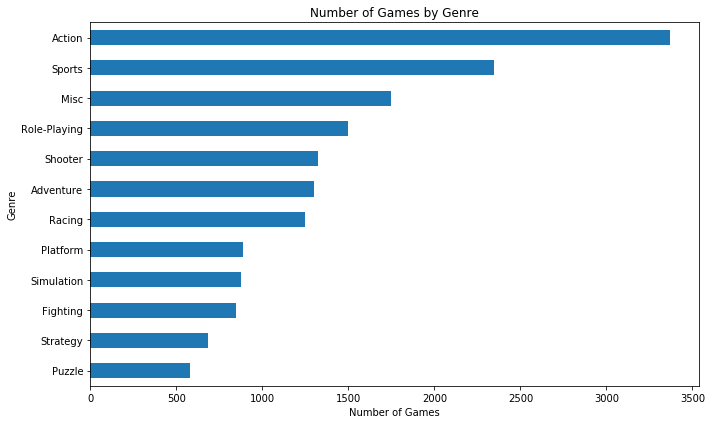


### Analysis

The genre distribution shows that **Action** is the most represented genre
in the dataset, with **3,370 games**, accounting for approximately
**20.2%** of the games included in this analysis.

In contrast, **Puzzle** is the least represented genre, with
**580 games**, representing approximately **3.5%**
of the dataset.

There is a difference of **2,790 games** between the most and least
represented genres. This indicates that the dataset has an uneven distribution
across game genres, which should be considered when comparing genres in later
analyses.


In [40]:
# Genre Distribution Analysis and Visualization

from IPython.display import display, Markdown

# Calculate genre counts dynamically
genre_counts = df_clean['Genre'].value_counts()

# Identify the highest and lowest represented genres
highest_genre = genre_counts.idxmax()
highest_count = genre_counts.max()

lowest_genre = genre_counts.idxmin()
lowest_count = genre_counts.min()

# Calculate the difference between highest and lowest
difference = highest_count - lowest_count

# Calculate representation percentage
total_games = genre_counts.sum()

highest_percentage = (highest_count / total_games) * 100
lowest_percentage = (lowest_count / total_games) * 100

# Create the chart
plt.figure(figsize=(10, 6))

genre_counts.sort_values(ascending=True).plot(
    kind='barh'
)

plt.title('Number of Games by Genre')
plt.xlabel('Number of Games')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

# Generate the analysis automatically
analysis_text = f"""
### Analysis

The genre distribution shows that **{highest_genre}** is the most represented genre
in the dataset, with **{highest_count:,} games**, accounting for approximately
**{highest_percentage:.1f}%** of the games included in this analysis.

In contrast, **{lowest_genre}** is the least represented genre, with
**{lowest_count:,} games**, representing approximately **{lowest_percentage:.1f}%**
of the dataset.

There is a difference of **{difference:,} games** between the most and least
represented genres. This indicates that the dataset has an uneven distribution
across game genres, which should be considered when comparing genres in later
analyses.
"""

display(Markdown(analysis_text))

In [ ]:
# Platform Distribution Analysis and Visualization

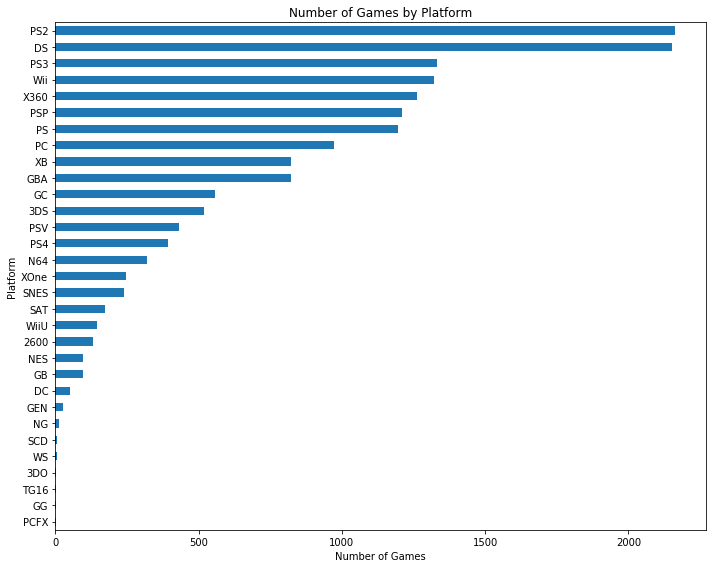


### Analysis

The platform distribution shows that **PS2** is the most
represented platform in the dataset, with **2,161 games**,
accounting for approximately **12.9%** of the games.

The least represented platform group consists of **GG**, **PCFX**,
with **1 game** each,
representing approximately **0.01%** of the dataset.

The difference between the most represented platform and the least represented
platform group is **2,160 games**, indicating that the dataset contains
an uneven distribution of games across platforms.


In [42]:
# Platform Distribution Analysis and Visualization

from IPython.display import display, Markdown

# Calculate platform counts dynamically
platform_counts = df_clean['Platform'].value_counts()

# Identify the most represented platform
highest_platform = platform_counts.idxmax()
highest_count = platform_counts.max()

# Identify all platforms tied for the lowest representation
lowest_count = platform_counts.min()
lowest_platforms = platform_counts[platform_counts == lowest_count].index.tolist()

# Calculate total games and percentages
total_games = platform_counts.sum()

highest_percentage = (highest_count / total_games) * 100
lowest_percentage = (lowest_count / total_games) * 100

# Calculate difference
difference = highest_count - lowest_count

# Format the lowest-platform names dynamically
if len(lowest_platforms) == 1:
    lowest_platform_text = f"**{lowest_platforms[0]}**"
else:
    lowest_platform_text = ", ".join(
        f"**{platform}**" for platform in lowest_platforms
    )

# Create the chart
plt.figure(figsize=(10, 8))

platform_counts.sort_values(ascending=True).plot(
    kind='barh'
)

plt.title('Number of Games by Platform')
plt.xlabel('Number of Games')
plt.ylabel('Platform')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The platform distribution shows that **{highest_platform}** is the most
represented platform in the dataset, with **{highest_count:,} games**,
accounting for approximately **{highest_percentage:.1f}%** of the games.

The least represented platform group consists of {lowest_platform_text},
with **{lowest_count:,} game{'s' if lowest_count != 1 else ''}** each,
representing approximately **{lowest_percentage:.2f}%** of the dataset.

The difference between the most represented platform and the least represented
platform group is **{difference:,} games**, indicating that the dataset contains
an uneven distribution of games across platforms.
"""

display(Markdown(analysis_text))

In [ ]:
# Global Sales Distribution Analysis and Visualization

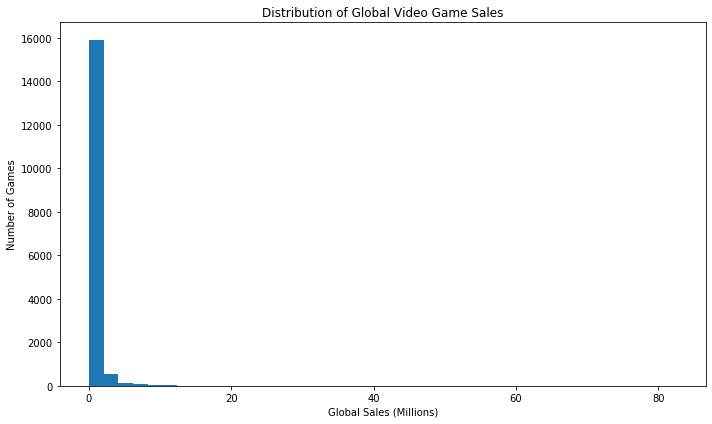


### Analysis

The distribution of global sales ranges from **0.01 million** to
**82.53 million** units, with a mean of **0.53 million**
and a median of **0.17 million**.

The mean is higher than the median, indicating that the distribution is positively skewed.

The difference between the mean and median suggests that the distribution
should be considered when interpreting average sales, particularly when
comparing different genres and platforms.


In [43]:
from IPython.display import display, Markdown

# Calculate sales statistics dynamically
sales = df_clean['Global_Sales'].dropna()

mean_sales = sales.mean()
median_sales = sales.median()
min_sales = sales.min()
max_sales = sales.max()

# Create the histogram
plt.figure(figsize=(10, 6))

plt.hist(
    sales,
    bins=40
)

plt.title('Distribution of Global Video Game Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
if mean_sales > median_sales:
    distribution_pattern = "The mean is higher than the median, indicating that the distribution is positively skewed."
elif mean_sales < median_sales:
    distribution_pattern = "The mean is lower than the median, indicating that the distribution is negatively skewed."
else:
    distribution_pattern = "The mean and median are equal, indicating a relatively balanced distribution."

analysis_text = f"""
### Analysis

The distribution of global sales ranges from **{min_sales:.2f} million** to
**{max_sales:.2f} million** units, with a mean of **{mean_sales:.2f} million**
and a median of **{median_sales:.2f} million**.

{distribution_pattern}

The difference between the mean and median suggests that the distribution
should be considered when interpreting average sales, particularly when
comparing different genres and platforms.
"""

display(Markdown(analysis_text))

In [ ]:
# Global Sales by Genre Analysis and Visualization

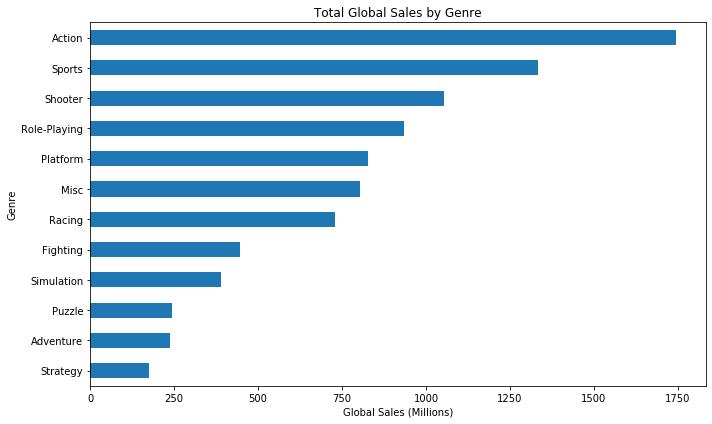


### Analysis

The distribution of total global sales by genre shows that **Action**
has the highest total global sales in the dataset, with approximately
**1745.27 million units**, representing **19.6%**
of the total global sales.

In contrast, **Strategy** has the lowest total global sales, with
approximately **174.50 million units**, representing
**2.0%** of the total.

The difference between the highest and lowest genre sales is approximately
**1570.77 million units**. This shows that total sales vary
substantially across genres and provides a basis for comparing genre-level
commercial performance.


In [44]:
from IPython.display import display, Markdown

# Calculate total global sales by genre
genre_sales = (
    df_clean.groupby('Genre')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
)

# Identify highest and lowest total sales
highest_genre = genre_sales.idxmax()
highest_sales = genre_sales.max()

lowest_genre = genre_sales.idxmin()
lowest_sales = genre_sales.min()

# Calculate total global sales
total_global_sales = genre_sales.sum()

# Calculate percentages
highest_percentage = (highest_sales / total_global_sales) * 100
lowest_percentage = (lowest_sales / total_global_sales) * 100

# Calculate difference
sales_difference = highest_sales - lowest_sales

# Create the chart
plt.figure(figsize=(10, 6))

genre_sales.sort_values(ascending=True).plot(
    kind='barh'
)

plt.title('Total Global Sales by Genre')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The distribution of total global sales by genre shows that **{highest_genre}**
has the highest total global sales in the dataset, with approximately
**{highest_sales:.2f} million units**, representing **{highest_percentage:.1f}%**
of the total global sales.

In contrast, **{lowest_genre}** has the lowest total global sales, with
approximately **{lowest_sales:.2f} million units**, representing
**{lowest_percentage:.1f}%** of the total.

The difference between the highest and lowest genre sales is approximately
**{sales_difference:.2f} million units**. This shows that total sales vary
substantially across genres and provides a basis for comparing genre-level
commercial performance.
"""

display(Markdown(analysis_text))

In [ ]:
# Average Global Sales by Genre Analysis and Visualization

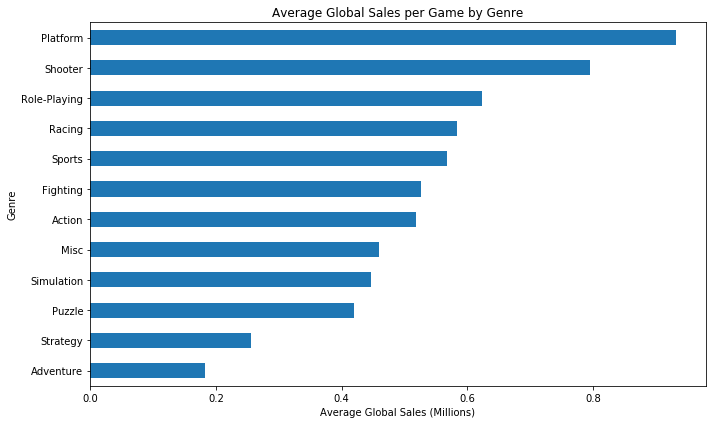


### Analysis

The average global sales analysis shows that **Platform** has the
highest average sales per game, with approximately **0.93
million units per game**.

In contrast, **Adventure** has the lowest average sales per game, with
approximately **0.18 million units per game**.

The difference between the highest and lowest average sales is approximately
**0.75 million units per game**. This comparison provides
a different perspective from total sales because it accounts for the number
of games represented within each genre.


In [45]:
from IPython.display import display, Markdown

# Calculate average global sales per game by genre
genre_avg_sales = (
    df_clean.groupby('Genre')['Global_Sales']
    .mean()
    .sort_values(ascending=False)
)

# Identify highest and lowest average sales
highest_genre = genre_avg_sales.idxmax()
highest_average = genre_avg_sales.max()

lowest_genre = genre_avg_sales.idxmin()
lowest_average = genre_avg_sales.min()

# Calculate the difference
average_difference = highest_average - lowest_average

# Create the chart
plt.figure(figsize=(10, 6))

genre_avg_sales.sort_values(ascending=True).plot(
    kind='barh'
)

plt.title('Average Global Sales per Game by Genre')
plt.xlabel('Average Global Sales (Millions)')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The average global sales analysis shows that **{highest_genre}** has the
highest average sales per game, with approximately **{highest_average:.2f}
million units per game**.

In contrast, **{lowest_genre}** has the lowest average sales per game, with
approximately **{lowest_average:.2f} million units per game**.

The difference between the highest and lowest average sales is approximately
**{average_difference:.2f} million units per game**. This comparison provides
a different perspective from total sales because it accounts for the number
of games represented within each genre.
"""

display(Markdown(analysis_text))

In [ ]:
# Median Global Sales by Genre Analysis and Visualization

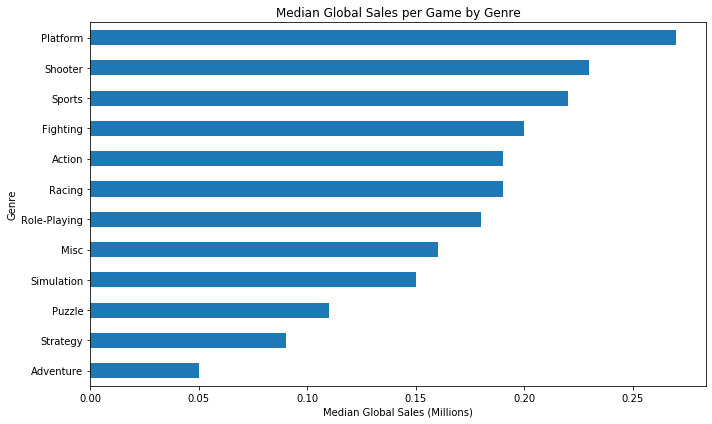


### Analysis

The median global sales analysis shows that **Platform** has the
highest median sales per game, with approximately **0.27
million units per game**.

In contrast, **Adventure** has the lowest median sales per game, with
approximately **0.05 million units per game**.

The difference between the highest and lowest median sales is approximately
**0.22 million units per game**.

Because the median is less affected by extremely high sales values than the
mean, this analysis provides an additional view of the typical sales level
within each genre.


In [46]:
from IPython.display import display, Markdown

# Calculate median global sales per game by genre
genre_median_sales = (
    df_clean.groupby('Genre')['Global_Sales']
    .median()
    .sort_values(ascending=False)
)

# Identify highest and lowest median sales
highest_genre = genre_median_sales.idxmax()
highest_median = genre_median_sales.max()

lowest_genre = genre_median_sales.idxmin()
lowest_median = genre_median_sales.min()

# Calculate the difference
median_difference = highest_median - lowest_median

# Create the chart
plt.figure(figsize=(10, 6))

genre_median_sales.sort_values(ascending=True).plot(
    kind='barh'
)

plt.title('Median Global Sales per Game by Genre')
plt.xlabel('Median Global Sales (Millions)')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The median global sales analysis shows that **{highest_genre}** has the
highest median sales per game, with approximately **{highest_median:.2f}
million units per game**.

In contrast, **{lowest_genre}** has the lowest median sales per game, with
approximately **{lowest_median:.2f} million units per game**.

The difference between the highest and lowest median sales is approximately
**{median_difference:.2f} million units per game**.

Because the median is less affected by extremely high sales values than the
mean, this analysis provides an additional view of the typical sales level
within each genre.
"""

display(Markdown(analysis_text))

In [ ]:
# Global Sales by Platform Analysis and Visualization

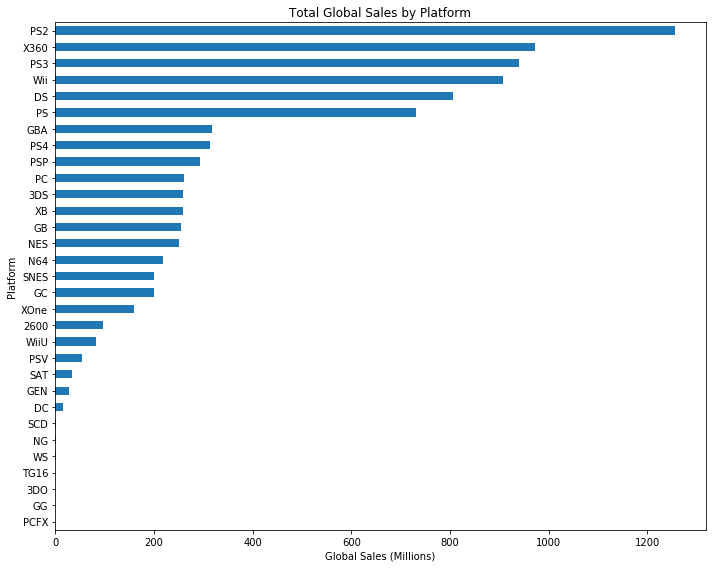


### Analysis

The platform sales distribution shows that **PS2** has the
highest total global sales in the dataset, with approximately
**1255.64 million units**, representing
**14.1%** of the total global sales.

The platform with the lowest total global sales is
**PCFX**, with approximately **0.03 million units**
in total, representing **0.00%** of the total.

The difference between the highest and lowest platform sales is approximately
**1255.61 million units**. This shows substantial variation
in total global sales across platforms. However, total sales are also
influenced by the number of games available on each platform, so further
analysis of average and median sales per game is needed for a more complete
comparison.


In [48]:
from IPython.display import display, Markdown

# Calculate total global sales by platform
platform_sales = (
    df_clean.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
)

# Identify the highest and lowest sales platforms
highest_platform = platform_sales.idxmax()
highest_sales = platform_sales.max()

lowest_sales = platform_sales.min()
lowest_platforms = platform_sales[
    platform_sales == lowest_sales
].index.tolist()

# Calculate total global sales
total_global_sales = platform_sales.sum()

# Calculate percentages
highest_percentage = (highest_sales / total_global_sales) * 100
lowest_percentage = (lowest_sales / total_global_sales) * 100

# Calculate difference
sales_difference = highest_sales - lowest_sales

# Format lowest-platform names dynamically
if len(lowest_platforms) == 1:
    lowest_platform_text = f"**{lowest_platforms[0]}**"
else:
    lowest_platform_text = ", ".join(
        f"**{platform}**" for platform in lowest_platforms
    )

# Create the chart
plt.figure(figsize=(10, 8))

platform_sales.sort_values(ascending=True).plot(
    kind='barh'
)

plt.title('Total Global Sales by Platform')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Platform')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The platform sales distribution shows that **{highest_platform}** has the
highest total global sales in the dataset, with approximately
**{highest_sales:.2f} million units**, representing
**{highest_percentage:.1f}%** of the total global sales.

The platform with the lowest total global sales is
{lowest_platform_text}, with approximately **{lowest_sales:.2f} million units**
in total, representing **{lowest_percentage:.2f}%** of the total.

The difference between the highest and lowest platform sales is approximately
**{sales_difference:.2f} million units**. This shows substantial variation
in total global sales across platforms. However, total sales are also
influenced by the number of games available on each platform, so further
analysis of average and median sales per game is needed for a more complete
comparison.
"""

display(Markdown(analysis_text))

In [ ]:
# Average Global Sales per Game by Platform

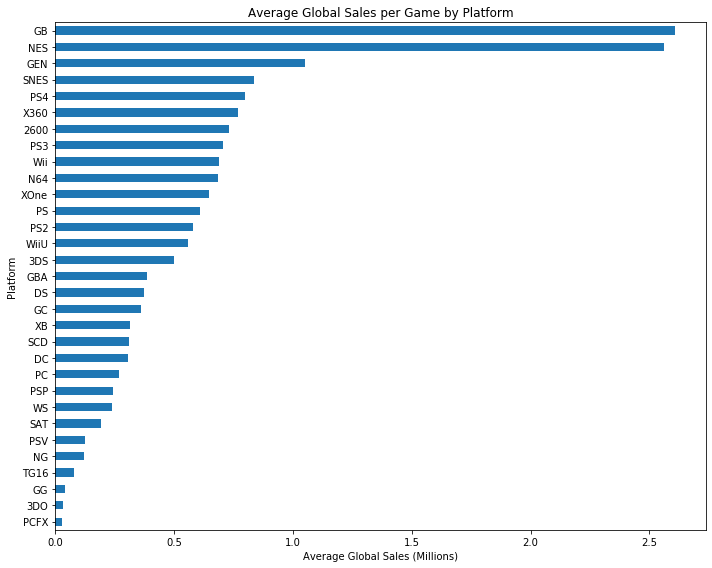


### Analysis

The average global sales analysis shows that **GB** has the
highest average sales per game, with approximately **2.61
million units per game**. This average is based on **98
games** in the dataset.

The platform group with the lowest average sales per game is
**PCFX**, with approximately **0.03 million
units per game**.

The difference between the highest and lowest average sales is approximately
**2.58 million units per game**.

Because the average can be strongly influenced by platforms with a small
number of games, the number of games represented by each platform should be
considered when interpreting this comparison.


In [50]:
from IPython.display import display, Markdown

# Calculate average sales and number of games for each platform
platform_analysis = (
    df_clean.groupby('Platform')
    .agg(
        Average_Global_Sales=('Global_Sales', 'mean'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_values('Average_Global_Sales', ascending=False)
)

# Identify highest and lowest average sales
highest_platform = platform_analysis['Average_Global_Sales'].idxmax()
highest_average = platform_analysis['Average_Global_Sales'].max()
highest_game_count = platform_analysis.loc[
    highest_platform, 'Number_of_Games'
]

lowest_average = platform_analysis['Average_Global_Sales'].min()
lowest_platforms = platform_analysis[
    platform_analysis['Average_Global_Sales'] == lowest_average
].index.tolist()

# Calculate difference
average_difference = highest_average - lowest_average

# Format lowest-platform names dynamically
if len(lowest_platforms) == 1:
    lowest_platform_text = f"**{lowest_platforms[0]}**"
else:
    lowest_platform_text = ", ".join(
        f"**{platform}**" for platform in lowest_platforms
    )

# Create the chart
plt.figure(figsize=(10, 8))

platform_analysis['Average_Global_Sales'].sort_values(
    ascending=True
).plot(kind='barh')

plt.title('Average Global Sales per Game by Platform')
plt.xlabel('Average Global Sales (Millions)')
plt.ylabel('Platform')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The average global sales analysis shows that **{highest_platform}** has the
highest average sales per game, with approximately **{highest_average:.2f}
million units per game**. This average is based on **{highest_game_count:,}
games** in the dataset.

The platform group with the lowest average sales per game is
{lowest_platform_text}, with approximately **{lowest_average:.2f} million
units per game**.

The difference between the highest and lowest average sales is approximately
**{average_difference:.2f} million units per game**.

Because the average can be strongly influenced by platforms with a small
number of games, the number of games represented by each platform should be
considered when interpreting this comparison.
"""

display(Markdown(analysis_text))

In [ ]:
# Median Global Sales per Game by Platform

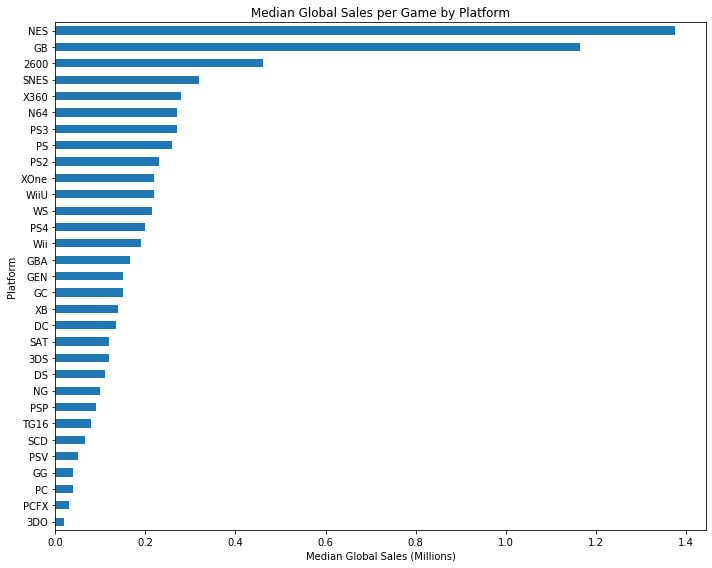


### Analysis

The median global sales analysis shows that **NES** has the
highest median sales per game, with approximately **1.38
million units per game**. This result is based on **98
games** in the dataset.

The platform group with the lowest median sales per game is
**3DO**, with approximately **0.02 million
units per game**.

The difference between the highest and lowest median sales is approximately
**1.35 million units per game**.

Because the median is less affected by extremely high sales values than the
mean, this analysis provides an additional view of the typical sales level
for games on each platform.


In [51]:
from IPython.display import display, Markdown

# Calculate median sales and number of games for each platform
platform_median_analysis = (
    df_clean.groupby('Platform')
    .agg(
        Median_Global_Sales=('Global_Sales', 'median'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_values('Median_Global_Sales', ascending=False)
)

# Identify highest and lowest median sales
highest_platform = platform_median_analysis['Median_Global_Sales'].idxmax()
highest_median = platform_median_analysis['Median_Global_Sales'].max()
highest_game_count = platform_median_analysis.loc[
    highest_platform, 'Number_of_Games'
]

lowest_median = platform_median_analysis['Median_Global_Sales'].min()
lowest_platforms = platform_median_analysis[
    platform_median_analysis['Median_Global_Sales'] == lowest_median
].index.tolist()

# Calculate difference
median_difference = highest_median - lowest_median

# Format lowest-platform names dynamically
if len(lowest_platforms) == 1:
    lowest_platform_text = f"**{lowest_platforms[0]}**"
else:
    lowest_platform_text = ", ".join(
        f"**{platform}**" for platform in lowest_platforms
    )

# Create the chart
plt.figure(figsize=(10, 8))

platform_median_analysis['Median_Global_Sales'].sort_values(
    ascending=True
).plot(kind='barh')

plt.title('Median Global Sales per Game by Platform')
plt.xlabel('Median Global Sales (Millions)')
plt.ylabel('Platform')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The median global sales analysis shows that **{highest_platform}** has the
highest median sales per game, with approximately **{highest_median:.2f}
million units per game**. This result is based on **{highest_game_count:,}
games** in the dataset.

The platform group with the lowest median sales per game is
{lowest_platform_text}, with approximately **{lowest_median:.2f} million
units per game**.

The difference between the highest and lowest median sales is approximately
**{median_difference:.2f} million units per game**.

Because the median is less affected by extremely high sales values than the
mean, this analysis provides an additional view of the typical sales level
for games on each platform.
"""

display(Markdown(analysis_text))

In [ ]:
# Critic Score Distribution Analysis and Visualization

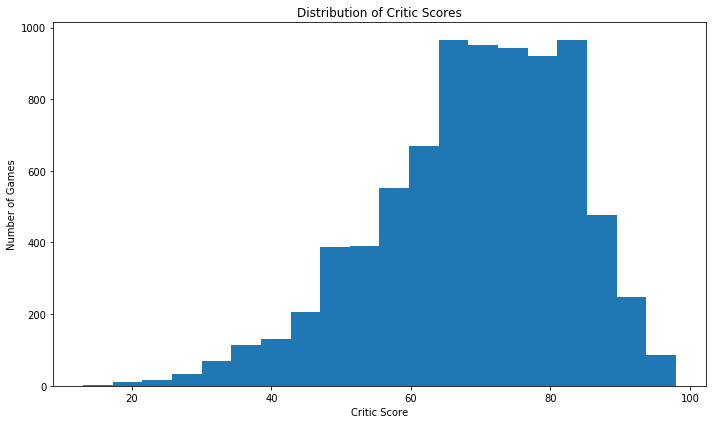


### Analysis

The available critic scores range from **13** to
**98**, with a mean of **68.97** and a median of
**71.00**.

A total of **8,137 games** have an available critic score, while
**8,580 games (51.3%)** have no critic score.

The mean is lower than the median, indicating a negative left-skew in the available critic scores.

The missing critic scores are retained in the dataset and are excluded only
from analyses that specifically require an available critic score.


In [52]:
from IPython.display import display, Markdown

# Use only available critic scores
critic_scores = df_clean['Critic_Score'].dropna()

# Calculate statistics dynamically
score_count = critic_scores.count()
missing_count = df_clean['Critic_Score'].isna().sum()

total_games = len(df_clean)

missing_percentage = (missing_count / total_games) * 100

mean_score = critic_scores.mean()
median_score = critic_scores.median()

min_score = critic_scores.min()
max_score = critic_scores.max()

# Create the histogram
plt.figure(figsize=(10, 6))

plt.hist(
    critic_scores,
    bins=20
)

plt.title('Distribution of Critic Scores')
plt.xlabel('Critic Score')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
if mean_score > median_score:
    distribution_pattern = (
        "The mean is higher than the median, indicating a positive "
        "right-skew in the available critic scores."
    )
elif mean_score < median_score:
    distribution_pattern = (
        "The mean is lower than the median, indicating a negative "
        "left-skew in the available critic scores."
    )
else:
    distribution_pattern = (
        "The mean and median are equal, indicating a relatively "
        "balanced distribution."
    )

analysis_text = f"""
### Analysis

The available critic scores range from **{min_score:.0f}** to
**{max_score:.0f}**, with a mean of **{mean_score:.2f}** and a median of
**{median_score:.2f}**.

A total of **{score_count:,} games** have an available critic score, while
**{missing_count:,} games ({missing_percentage:.1f}%)** have no critic score.

{distribution_pattern}

The missing critic scores are retained in the dataset and are excluded only
from analyses that specifically require an available critic score.
"""

display(Markdown(analysis_text))

In [ ]:
# User Score Distribution Analysis and Visualization

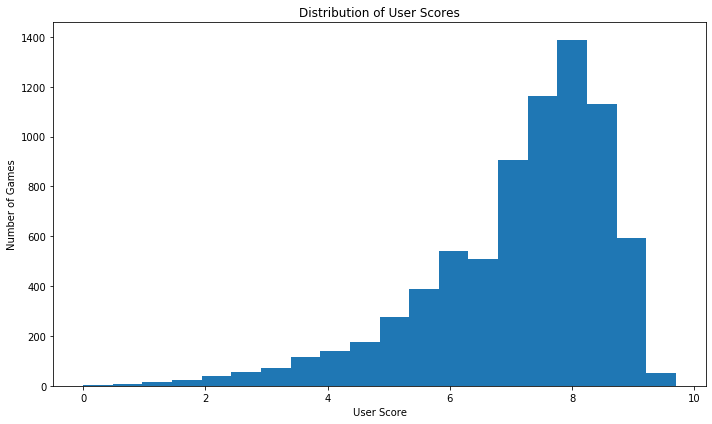


### Analysis

The available user scores range from **0.0** to
**9.7**, with a mean of **7.13** and a median of
**7.50**.

A total of **7,590 games** have an available user score, while
**9,127 games (54.6%)** have no user score.

The mean is lower than the median, indicating a negative left-skew in the available user scores.

The missing user scores are retained in the dataset and are excluded only
from analyses that specifically require an available user score.


In [53]:
from IPython.display import display, Markdown

# Use only available user scores
user_scores = df_clean['User_Score'].dropna()

# Calculate statistics dynamically
score_count = user_scores.count()
missing_count = df_clean['User_Score'].isna().sum()

total_games = len(df_clean)

missing_percentage = (missing_count / total_games) * 100

mean_score = user_scores.mean()
median_score = user_scores.median()

min_score = user_scores.min()
max_score = user_scores.max()

# Create the histogram
plt.figure(figsize=(10, 6))

plt.hist(
    user_scores,
    bins=20
)

plt.title('Distribution of User Scores')
plt.xlabel('User Score')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

# Determine distribution pattern dynamically
if mean_score > median_score:
    distribution_pattern = (
        "The mean is higher than the median, indicating a positive "
        "right-skew in the available user scores."
    )
elif mean_score < median_score:
    distribution_pattern = (
        "The mean is lower than the median, indicating a negative "
        "left-skew in the available user scores."
    )
else:
    distribution_pattern = (
        "The mean and median are equal, indicating a relatively "
        "balanced distribution."
    )

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The available user scores range from **{min_score:.1f}** to
**{max_score:.1f}**, with a mean of **{mean_score:.2f}** and a median of
**{median_score:.2f}**.

A total of **{score_count:,} games** have an available user score, while
**{missing_count:,} games ({missing_percentage:.1f}%)** have no user score.

{distribution_pattern}

The missing user scores are retained in the dataset and are excluded only
from analyses that specifically require an available user score.
"""

display(Markdown(analysis_text))

In [ ]:
# Critic Score vs Global Sales Analysis

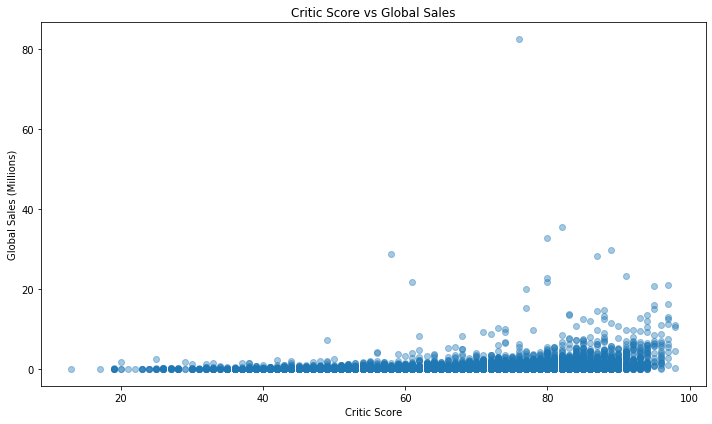


### Analysis

The analysis includes **8,137 games** with both an available critic
score and global sales value.

The Pearson correlation between **Critic Score** and **Global Sales** is
**0.245**, indicating an **weak positive linear
relationship** between the two variables in the available data.

The average critic score in this subset is **68.97**, while the
average global sales is **0.69 million units**.

The scatter plot shows how global sales vary across different critic scores.
The correlation describes the strength and direction of the linear association
in the available observations; it does not establish that critic scores cause
higher or lower sales.


In [54]:
from IPython.display import display, Markdown

# Select rows where both variables are available
critic_sales_data = df_clean[
    ['Critic_Score', 'Global_Sales']
].dropna()

# Calculate statistics dynamically
sample_size = len(critic_sales_data)

critic_mean = critic_sales_data['Critic_Score'].mean()
sales_mean = critic_sales_data['Global_Sales'].mean()

correlation = critic_sales_data[
    'Critic_Score'
].corr(
    critic_sales_data['Global_Sales']
)

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    critic_sales_data['Critic_Score'],
    critic_sales_data['Global_Sales'],
    alpha=0.4
)

plt.title('Critic Score vs Global Sales')
plt.xlabel('Critic Score')
plt.ylabel('Global Sales (Millions)')

plt.tight_layout()
plt.show()

# Interpret correlation dynamically
if correlation >= 0.7:
    correlation_strength = "strong positive"
elif correlation >= 0.3:
    correlation_strength = "moderate positive"
elif correlation > 0:
    correlation_strength = "weak positive"
elif correlation <= -0.7:
    correlation_strength = "strong negative"
elif correlation <= -0.3:
    correlation_strength = "moderate negative"
elif correlation < 0:
    correlation_strength = "weak negative"
else:
    correlation_strength = "approximately no linear"

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The analysis includes **{sample_size:,} games** with both an available critic
score and global sales value.

The Pearson correlation between **Critic Score** and **Global Sales** is
**{correlation:.3f}**, indicating an **{correlation_strength} linear
relationship** between the two variables in the available data.

The average critic score in this subset is **{critic_mean:.2f}**, while the
average global sales is **{sales_mean:.2f} million units**.

The scatter plot shows how global sales vary across different critic scores.
The correlation describes the strength and direction of the linear association
in the available observations; it does not establish that critic scores cause
higher or lower sales.
"""

display(Markdown(analysis_text))

In [ ]:
# User Score vs Global Sales Analysis

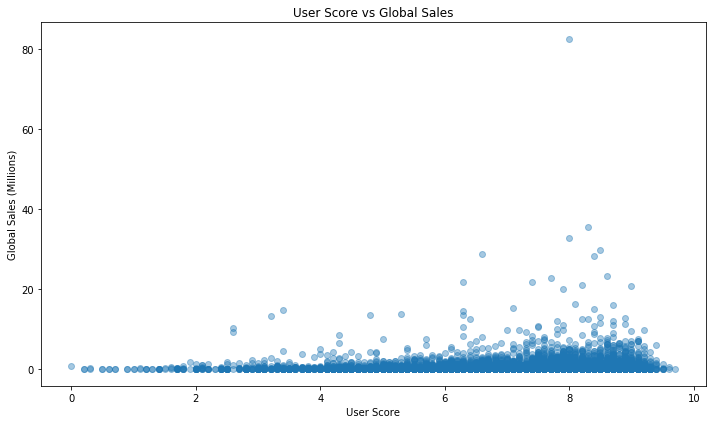


### Analysis

The analysis includes **7,590 games** with both an available user
score and global sales value.

The Pearson correlation between **User Score** and **Global Sales** is
**0.088**, indicating a **weak positive linear
relationship** between the two variables in the available data.

The average user score in this subset is **7.13**, while the
average global sales is **0.74 million units**.

The scatter plot shows how global sales vary across different user scores.
The correlation describes the strength and direction of the linear association
in the available observations; it does not establish that user scores cause
higher or lower sales.


In [55]:
from IPython.display import display, Markdown

# Select rows where both variables are available
user_sales_data = df_clean[
    ['User_Score', 'Global_Sales']
].dropna()

# Calculate statistics dynamically
sample_size = len(user_sales_data)

user_mean = user_sales_data['User_Score'].mean()
sales_mean = user_sales_data['Global_Sales'].mean()

correlation = user_sales_data[
    'User_Score'
].corr(
    user_sales_data['Global_Sales']
)

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    user_sales_data['User_Score'],
    user_sales_data['Global_Sales'],
    alpha=0.4
)

plt.title('User Score vs Global Sales')
plt.xlabel('User Score')
plt.ylabel('Global Sales (Millions)')

plt.tight_layout()
plt.show()

# Interpret correlation dynamically
if correlation >= 0.7:
    correlation_strength = "strong positive"
elif correlation >= 0.3:
    correlation_strength = "moderate positive"
elif correlation > 0:
    correlation_strength = "weak positive"
elif correlation <= -0.7:
    correlation_strength = "strong negative"
elif correlation <= -0.3:
    correlation_strength = "moderate negative"
elif correlation < 0:
    correlation_strength = "weak negative"
else:
    correlation_strength = "approximately no linear"

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The analysis includes **{sample_size:,} games** with both an available user
score and global sales value.

The Pearson correlation between **User Score** and **Global Sales** is
**{correlation:.3f}**, indicating a **{correlation_strength} linear
relationship** between the two variables in the available data.

The average user score in this subset is **{user_mean:.2f}**, while the
average global sales is **{sales_mean:.2f} million units**.

The scatter plot shows how global sales vary across different user scores.
The correlation describes the strength and direction of the linear association
in the available observations; it does not establish that user scores cause
higher or lower sales.
"""

display(Markdown(analysis_text))

In [ ]:
# ESRB Rating Distribution Analysis and Visualization

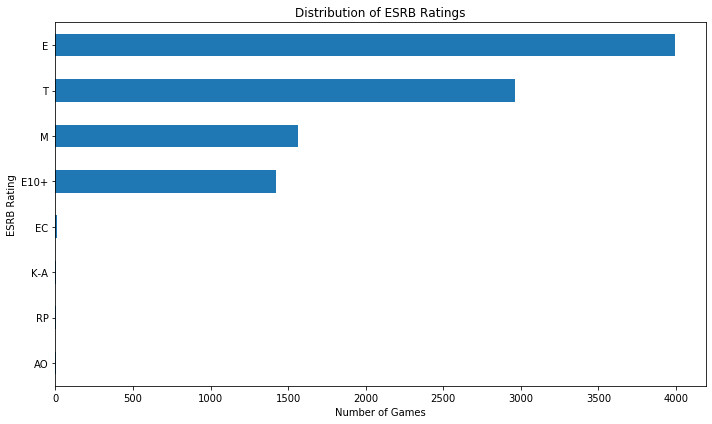


### Analysis

Among games with an available ESRB rating, **E** is the most
common rating, with **3,991 games**, representing approximately
**40.1%** of the games with an available rating.

The least common rating group consists of **AO**, with
**1 game** each.

A total of **6,767 games (40.5%)**
do not have an available ESRB rating. These missing ratings are retained in
the dataset and are excluded from the rating distribution analysis.


In [56]:
from IPython.display import display, Markdown

# Use only available ESRB ratings
rating_counts = df_clean['Rating'].dropna().value_counts()

# Calculate missing ratings
missing_rating_count = df_clean['Rating'].isna().sum()
total_games = len(df_clean)

missing_rating_percentage = (
    missing_rating_count / total_games
) * 100

# Identify the most and least common available ratings
highest_rating = rating_counts.idxmax()
highest_count = rating_counts.max()

lowest_count = rating_counts.min()
lowest_ratings = rating_counts[
    rating_counts == lowest_count
].index.tolist()

# Calculate percentage of the most common rating
highest_percentage = (
    highest_count / rating_counts.sum()
) * 100

# Format least common ratings dynamically
if len(lowest_ratings) == 1:
    lowest_rating_text = f"**{lowest_ratings[0]}**"
else:
    lowest_rating_text = ", ".join(
        f"**{rating}**" for rating in lowest_ratings
    )

# Create the chart
plt.figure(figsize=(10, 6))

rating_counts.sort_values(ascending=True).plot(
    kind='barh'
)

plt.title('Distribution of ESRB Ratings')
plt.xlabel('Number of Games')
plt.ylabel('ESRB Rating')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

Among games with an available ESRB rating, **{highest_rating}** is the most
common rating, with **{highest_count:,} games**, representing approximately
**{highest_percentage:.1f}%** of the games with an available rating.

The least common rating group consists of {lowest_rating_text}, with
**{lowest_count:,} game{'s' if lowest_count != 1 else ''}** each.

A total of **{missing_rating_count:,} games ({missing_rating_percentage:.1f}%)**
do not have an available ESRB rating. These missing ratings are retained in
the dataset and are excluded from the rating distribution analysis.
"""

display(Markdown(analysis_text))

In [ ]:
# Global Sales by ESRB Rating Analysis and Visualization

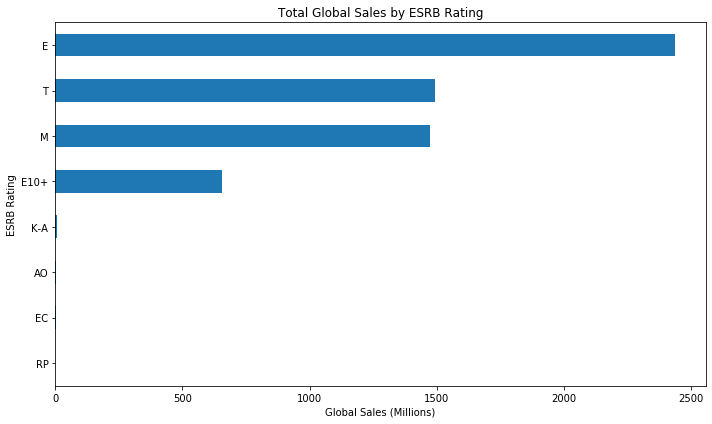


### Analysis

Among games with an available ESRB rating, **E** has the
highest total global sales, with approximately **2436.90 million
units**, representing **40.2%** of the total global sales
among rated games.

This total is based on **3,991 games** with the
**E** rating.

The rating with the lowest total global sales is **RP**, with
approximately **0.08 million units** in total.

The difference between the highest and lowest total sales is approximately
**2436.82 million units**.

Because total sales are influenced by the number of games within each rating
category, this result should be interpreted together with the number of games
represented by each rating.


In [57]:
from IPython.display import display, Markdown

# Calculate total sales and number of games for each ESRB rating
rating_sales_analysis = (
    df_clean.dropna(subset=['Rating'])
    .groupby('Rating')
    .agg(
        Total_Global_Sales=('Global_Sales', 'sum'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_values('Total_Global_Sales', ascending=False)
)

# Identify highest and lowest total sales ratings
highest_rating = rating_sales_analysis['Total_Global_Sales'].idxmax()
highest_sales = rating_sales_analysis['Total_Global_Sales'].max()
highest_game_count = rating_sales_analysis.loc[
    highest_rating, 'Number_of_Games'
]

lowest_sales = rating_sales_analysis['Total_Global_Sales'].min()
lowest_ratings = rating_sales_analysis[
    rating_sales_analysis['Total_Global_Sales'] == lowest_sales
].index.tolist()

# Calculate total sales across rated games
total_rated_sales = rating_sales_analysis['Total_Global_Sales'].sum()

# Calculate percentage of highest rating
highest_percentage = (
    highest_sales / total_rated_sales
) * 100

# Calculate difference
sales_difference = highest_sales - lowest_sales

# Format lowest-rating names dynamically
if len(lowest_ratings) == 1:
    lowest_rating_text = f"**{lowest_ratings[0]}**"
else:
    lowest_rating_text = ", ".join(
        f"**{rating}**" for rating in lowest_ratings
    )

# Create the chart
plt.figure(figsize=(10, 6))

rating_sales_analysis['Total_Global_Sales'].sort_values(
    ascending=True
).plot(kind='barh')

plt.title('Total Global Sales by ESRB Rating')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('ESRB Rating')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

Among games with an available ESRB rating, **{highest_rating}** has the
highest total global sales, with approximately **{highest_sales:.2f} million
units**, representing **{highest_percentage:.1f}%** of the total global sales
among rated games.

This total is based on **{highest_game_count:,} games** with the
**{highest_rating}** rating.

The rating with the lowest total global sales is {lowest_rating_text}, with
approximately **{lowest_sales:.2f} million units** in total.

The difference between the highest and lowest total sales is approximately
**{sales_difference:.2f} million units**.

Because total sales are influenced by the number of games within each rating
category, this result should be interpreted together with the number of games
represented by each rating.
"""

display(Markdown(analysis_text))

In [ ]:
# Average Global Sales per ESRB Rating

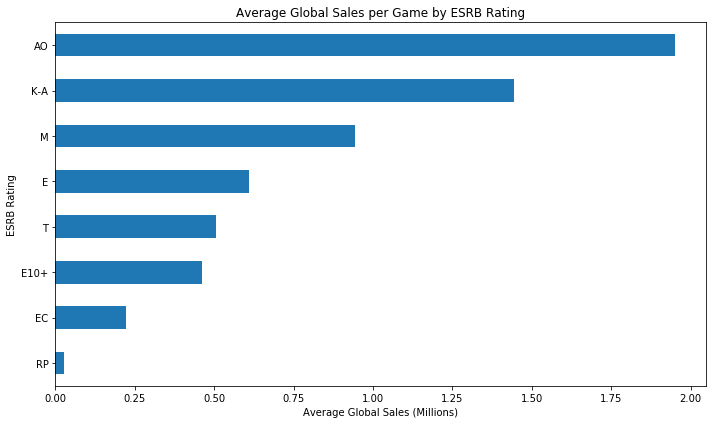


### Analysis

The average global sales analysis shows that **AO** has the
highest average sales per game, with approximately **1.95
million units per game**.

The highest average is based on only **1 game**, so it should be interpreted with substantial caution.

The rating group with the lowest average sales per game is
**RP**, with approximately **0.03 million units
per game**, based on **3 games**.

The difference between the highest and lowest average sales is approximately
**1.92 million units per game**.

Because average sales can be strongly influenced by ratings with very few
games, the number of observations within each rating should be considered
when interpreting this comparison.


In [59]:
from IPython.display import display, Markdown

# Calculate average sales and number of games for each ESRB rating
rating_avg_analysis = (
    df_clean.dropna(subset=['Rating'])
    .groupby('Rating')
    .agg(
        Average_Global_Sales=('Global_Sales', 'mean'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_values('Average_Global_Sales', ascending=False)
)

# Identify highest and lowest average sales
highest_rating = rating_avg_analysis['Average_Global_Sales'].idxmax()
highest_average = rating_avg_analysis['Average_Global_Sales'].max()
highest_game_count = rating_avg_analysis.loc[
    highest_rating, 'Number_of_Games'
]

lowest_average = rating_avg_analysis['Average_Global_Sales'].min()
lowest_ratings = rating_avg_analysis[
    rating_avg_analysis['Average_Global_Sales'] == lowest_average
].index.tolist()

lowest_game_count = rating_avg_analysis.loc[
    lowest_ratings[0], 'Number_of_Games'
]

# Calculate difference
average_difference = highest_average - lowest_average

# Format lowest-rating names dynamically
if len(lowest_ratings) == 1:
    lowest_rating_text = f"**{lowest_ratings[0]}**"
else:
    lowest_rating_text = ", ".join(
        f"**{rating}**" for rating in lowest_ratings
    )

# Determine whether the highest average is based on a small sample
if highest_game_count <= 5:
    highest_sample_note = (
        f"The highest average is based on only **{highest_game_count:,} "
        f"game{'s' if highest_game_count != 1 else ''}**, so it should be "
        "interpreted with substantial caution."
    )
elif highest_game_count <= 20:
    highest_sample_note = (
        f"The highest average is based on **{highest_game_count:,} games**, "
        "so the result should be interpreted with caution because the group "
        "has relatively few observations."
    )
else:
    highest_sample_note = (
        f"The highest average is based on **{highest_game_count:,} games**, "
        "providing a larger basis for the comparison."
    )

# Create the chart
plt.figure(figsize=(10, 6))

rating_avg_analysis['Average_Global_Sales'].sort_values(
    ascending=True
).plot(kind='barh')

plt.title('Average Global Sales per Game by ESRB Rating')
plt.xlabel('Average Global Sales (Millions)')
plt.ylabel('ESRB Rating')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The average global sales analysis shows that **{highest_rating}** has the
highest average sales per game, with approximately **{highest_average:.2f}
million units per game**.

{highest_sample_note}

The rating group with the lowest average sales per game is
{lowest_rating_text}, with approximately **{lowest_average:.2f} million units
per game**, based on **{lowest_game_count:,} game{'s' if lowest_game_count != 1 else ''}**.

The difference between the highest and lowest average sales is approximately
**{average_difference:.2f} million units per game**.

Because average sales can be strongly influenced by ratings with very few
games, the number of observations within each rating should be considered
when interpreting this comparison.
"""

display(Markdown(analysis_text))

In [ ]:
# Median Global Sales per ESRB Rating

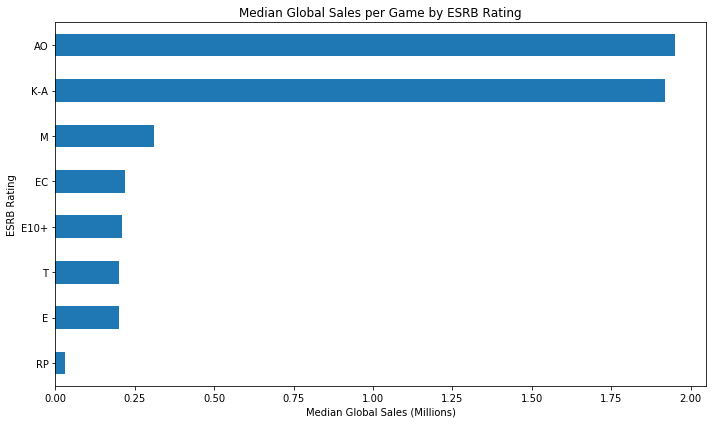


### Analysis

The median global sales analysis shows that **AO** has the
highest median sales per game, with approximately **1.95
million units per game**. This result is based on **1
games** in the dataset.

The rating group with the lowest median sales per game is
**RP**, with approximately **0.03 million units
per game**, based on **3 games**.

The difference between the highest and lowest median sales is approximately
**1.92 million units per game**.

Because the median is less affected by extremely high sales values than the
mean, this analysis provides an additional view of the typical sales level
within each ESRB rating.


In [60]:
from IPython.display import display, Markdown

# Calculate median sales and number of games for each ESRB rating
rating_median_analysis = (
    df_clean.dropna(subset=['Rating'])
    .groupby('Rating')
    .agg(
        Median_Global_Sales=('Global_Sales', 'median'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_values('Median_Global_Sales', ascending=False)
)

# Identify highest median sales
highest_rating = rating_median_analysis['Median_Global_Sales'].idxmax()
highest_median = rating_median_analysis['Median_Global_Sales'].max()
highest_game_count = rating_median_analysis.loc[
    highest_rating, 'Number_of_Games'
]

# Identify lowest median sales
lowest_median = rating_median_analysis['Median_Global_Sales'].min()
lowest_ratings = rating_median_analysis[
    rating_median_analysis['Median_Global_Sales'] == lowest_median
].index.tolist()

lowest_game_count = rating_median_analysis.loc[
    lowest_ratings[0], 'Number_of_Games'
]

# Calculate difference
median_difference = highest_median - lowest_median

# Format lowest-rating names dynamically
if len(lowest_ratings) == 1:
    lowest_rating_text = f"**{lowest_ratings[0]}**"
else:
    lowest_rating_text = ", ".join(
        f"**{rating}**" for rating in lowest_ratings
    )

# Create the chart
plt.figure(figsize=(10, 6))

rating_median_analysis['Median_Global_Sales'].sort_values(
    ascending=True
).plot(kind='barh')

plt.title('Median Global Sales per Game by ESRB Rating')
plt.xlabel('Median Global Sales (Millions)')
plt.ylabel('ESRB Rating')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The median global sales analysis shows that **{highest_rating}** has the
highest median sales per game, with approximately **{highest_median:.2f}
million units per game**. This result is based on **{highest_game_count:,}
games** in the dataset.

The rating group with the lowest median sales per game is
{lowest_rating_text}, with approximately **{lowest_median:.2f} million units
per game**, based on **{lowest_game_count:,} games**.

The difference between the highest and lowest median sales is approximately
**{median_difference:.2f} million units per game**.

Because the median is less affected by extremely high sales values than the
mean, this analysis provides an additional view of the typical sales level
within each ESRB rating.
"""

display(Markdown(analysis_text))

In [ ]:
# Global Sales Trend by Year

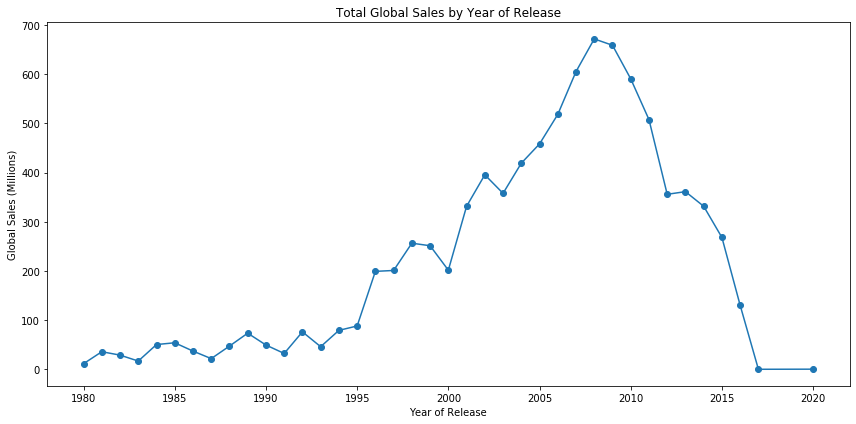


### Analysis

The yearly sales analysis shows that **2008** recorded the
highest total global sales, with approximately **671.79 million
units** across **1,427 games** with an available release year.

The sales recorded in **2008** represent approximately
**7.6%** of the total global sales included in this
year-based analysis.

The lowest total global sales were recorded in **2017**. However,
years with relatively few games should be interpreted carefully because total
sales are influenced by the number of games released in each year.

The analysis excludes **269 games**
with missing release years; these records remain in the cleaned dataset and
are excluded only from this time-based analysis.


In [61]:
from IPython.display import display, Markdown

# Use only games with an available release year
year_sales_analysis = (
    df_clean.dropna(subset=['Year_of_Release'])
    .groupby('Year_of_Release')
    .agg(
        Total_Global_Sales=('Global_Sales', 'sum'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_index()
)

# Identify the year with the highest total global sales
peak_year = year_sales_analysis['Total_Global_Sales'].idxmax()
peak_sales = year_sales_analysis['Total_Global_Sales'].max()
peak_game_count = year_sales_analysis.loc[
    peak_year, 'Number_of_Games'
]

# Identify the year with the lowest total sales
lowest_sales = year_sales_analysis['Total_Global_Sales'].min()
lowest_years = year_sales_analysis[
    year_sales_analysis['Total_Global_Sales'] == lowest_sales
].index.tolist()

# Calculate total sales across years with available release dates
total_sales_by_year = year_sales_analysis['Total_Global_Sales'].sum()

# Calculate peak year's percentage of total sales
peak_percentage = (
    peak_sales / total_sales_by_year
) * 100

# Format year values
peak_year_display = int(peak_year)

if len(lowest_years) == 1:
    lowest_year_text = f"**{int(lowest_years[0])}**"
else:
    lowest_year_text = ", ".join(
        f"**{int(year)}**" for year in lowest_years
    )

# Create the line chart
plt.figure(figsize=(12, 6))

plt.plot(
    year_sales_analysis.index,
    year_sales_analysis['Total_Global_Sales'],
    marker='o'
)

plt.title('Total Global Sales by Year of Release')
plt.xlabel('Year of Release')
plt.ylabel('Global Sales (Millions)')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The yearly sales analysis shows that **{peak_year_display}** recorded the
highest total global sales, with approximately **{peak_sales:.2f} million
units** across **{peak_game_count:,} games** with an available release year.

The sales recorded in **{peak_year_display}** represent approximately
**{peak_percentage:.1f}%** of the total global sales included in this
year-based analysis.

The lowest total global sales were recorded in {lowest_year_text}. However,
years with relatively few games should be interpreted carefully because total
sales are influenced by the number of games released in each year.

The analysis excludes **{df_clean['Year_of_Release'].isna().sum():,} games**
with missing release years; these records remain in the cleaned dataset and
are excluded only from this time-based analysis.
"""

display(Markdown(analysis_text))

In [ ]:
# Number of Games Released by Year

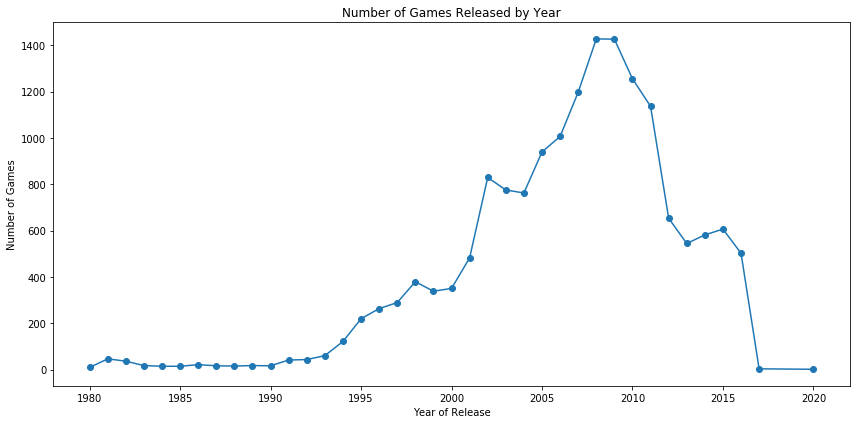


### Analysis

The yearly release analysis shows that **2008** had the
highest number of games released, with **1,427 games**.

The games released in **2008** represent approximately
**8.7%** of all games included in this year-based analysis.

The lowest number of games was recorded in **2020**, with
**1 game**.

The analysis includes **16,448 games** with an available
release year and excludes **269 games** with missing
release years. These records remain in the cleaned dataset and are excluded
only from this time-based analysis.


In [63]:
from IPython.display import display, Markdown

# Use only games with an available release year
year_games_analysis = (
    df_clean.dropna(subset=['Year_of_Release'])
    .groupby('Year_of_Release')
    .size()
    .sort_index()
)

# Identify the year with the highest number of games
peak_year = year_games_analysis.idxmax()
peak_game_count = year_games_analysis.max()

# Identify the year(s) with the lowest number of games
lowest_game_count = year_games_analysis.min()

lowest_years = year_games_analysis[
    year_games_analysis == lowest_game_count
].index.tolist()

# Total games included in the year-based analysis
total_games_by_year = year_games_analysis.sum()

# Calculate peak year's percentage
peak_percentage = (
    peak_game_count / total_games_by_year
) * 100

# Number of missing release years
missing_year_count = df_clean['Year_of_Release'].isna().sum()

# Format year values
peak_year_display = int(peak_year)

if len(lowest_years) == 1:
    lowest_year_text = f"**{int(lowest_years[0])}**"
else:
    lowest_year_text = ", ".join(
        f"**{int(year)}**" for year in lowest_years
    )

# Create the line chart
plt.figure(figsize=(12, 6))

plt.plot(
    year_games_analysis.index,
    year_games_analysis.values,
    marker='o'
)

plt.title('Number of Games Released by Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The yearly release analysis shows that **{peak_year_display}** had the
highest number of games released, with **{peak_game_count:,} games**.

The games released in **{peak_year_display}** represent approximately
**{peak_percentage:.1f}%** of all games included in this year-based analysis.

The lowest number of games was recorded in {lowest_year_text}, with
**{lowest_game_count:,} game{'s' if lowest_game_count != 1 else ''}**.

The analysis includes **{total_games_by_year:,} games** with an available
release year and excludes **{missing_year_count:,} games** with missing
release years. These records remain in the cleaned dataset and are excluded
only from this time-based analysis.
"""

display(Markdown(analysis_text))

In [ ]:
# Average Global Sales per Game by Year

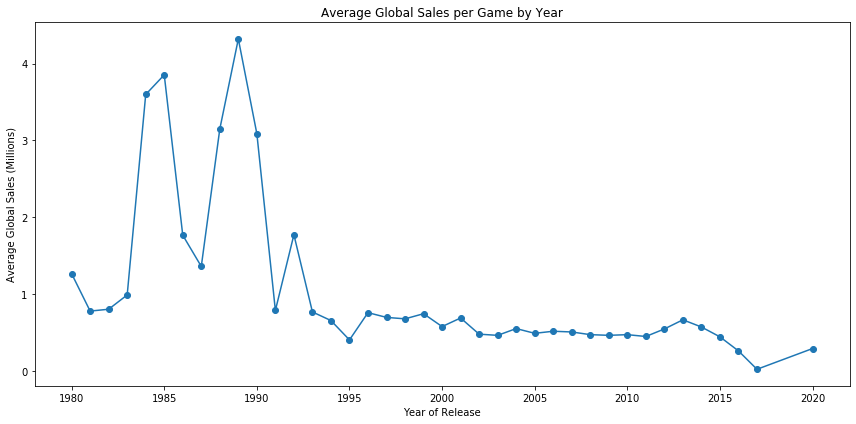


### Analysis

The average global sales analysis shows that **1989** had the
highest average global sales per game, with approximately
**4.32 million units per game**. This average is based on
**17 games**.

The year or years with the lowest average global sales per game are
**2017**, with approximately **0.02 million units
per game**, based on **3 games**.

The difference between the highest and lowest yearly average sales is
approximately **4.30 million units per game**.

Unlike total yearly sales, this measure accounts for the number of games
released in each year and provides a comparison of average sales per game.
Years with very few games should be interpreted with caution.


In [64]:
from IPython.display import display, Markdown

# Calculate average global sales and number of games for each year
year_avg_analysis = (
    df_clean.dropna(subset=['Year_of_Release'])
    .groupby('Year_of_Release')
    .agg(
        Average_Global_Sales=('Global_Sales', 'mean'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_index()
)

# Identify the year with the highest average sales
peak_year = year_avg_analysis['Average_Global_Sales'].idxmax()
peak_average = year_avg_analysis['Average_Global_Sales'].max()
peak_game_count = year_avg_analysis.loc[
    peak_year, 'Number_of_Games'
]

# Identify the year(s) with the lowest average sales
lowest_average = year_avg_analysis['Average_Global_Sales'].min()

lowest_years = year_avg_analysis[
    year_avg_analysis['Average_Global_Sales'] == lowest_average
].index.tolist()

lowest_game_count = year_avg_analysis.loc[
    lowest_years[0], 'Number_of_Games'
]

# Calculate difference
average_difference = peak_average - lowest_average

# Format year values
peak_year_display = int(peak_year)

if len(lowest_years) == 1:
    lowest_year_text = f"**{int(lowest_years[0])}**"
else:
    lowest_year_text = ", ".join(
        f"**{int(year)}**" for year in lowest_years
    )

# Create the line chart
plt.figure(figsize=(12, 6))

plt.plot(
    year_avg_analysis.index,
    year_avg_analysis['Average_Global_Sales'],
    marker='o'
)

plt.title('Average Global Sales per Game by Year')
plt.xlabel('Year of Release')
plt.ylabel('Average Global Sales (Millions)')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The average global sales analysis shows that **{peak_year_display}** had the
highest average global sales per game, with approximately
**{peak_average:.2f} million units per game**. This average is based on
**{peak_game_count:,} games**.

The year or years with the lowest average global sales per game are
{lowest_year_text}, with approximately **{lowest_average:.2f} million units
per game**, based on **{lowest_game_count:,} game{'s' if lowest_game_count != 1 else ''}**.

The difference between the highest and lowest yearly average sales is
approximately **{average_difference:.2f} million units per game**.

Unlike total yearly sales, this measure accounts for the number of games
released in each year and provides a comparison of average sales per game.
Years with very few games should be interpreted with caution.
"""

display(Markdown(analysis_text))

In [ ]:
# Median Global Sales per Game by Year

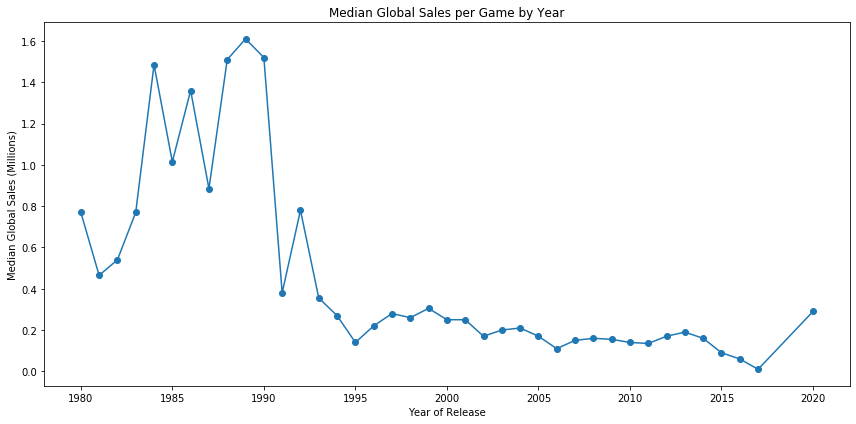


### Analysis

The median global sales analysis shows that **1989** had the
highest median global sales per game, with approximately
**1.61 million units per game**. This result is based on
**17 games**.

The year or years with the lowest median global sales per game are
**2017**, with approximately **0.01 million units
per game**, based on **3 games**.

The difference between the highest and lowest median sales is approximately
**1.60 million units per game**.

Because the median is less affected by extremely high sales values than the
mean, this analysis provides an additional view of the typical sales level
for games released in each year.

The analysis excludes **269 games** with missing release
years; these records remain in the cleaned dataset.


In [65]:
from IPython.display import display, Markdown

# Calculate median sales and number of games for each year
year_median_analysis = (
    df_clean.dropna(subset=['Year_of_Release'])
    .groupby('Year_of_Release')
    .agg(
        Median_Global_Sales=('Global_Sales', 'median'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_index()
)

# Identify the year with the highest median sales
peak_year = year_median_analysis['Median_Global_Sales'].idxmax()
peak_median = year_median_analysis['Median_Global_Sales'].max()
peak_game_count = year_median_analysis.loc[
    peak_year, 'Number_of_Games'
]

# Identify the year(s) with the lowest median sales
lowest_median = year_median_analysis['Median_Global_Sales'].min()

lowest_years = year_median_analysis[
    year_median_analysis['Median_Global_Sales'] == lowest_median
].index.tolist()

lowest_game_count = year_median_analysis.loc[
    lowest_years[0], 'Number_of_Games'
]

# Calculate difference
median_difference = peak_median - lowest_median

# Number of missing release years
missing_year_count = df_clean['Year_of_Release'].isna().sum()

# Format year values
peak_year_display = int(peak_year)

if len(lowest_years) == 1:
    lowest_year_text = f"**{int(lowest_years[0])}**"
else:
    lowest_year_text = ", ".join(
        f"**{int(year)}**" for year in lowest_years
    )

# Create the line chart
plt.figure(figsize=(12, 6))

plt.plot(
    year_median_analysis.index,
    year_median_analysis['Median_Global_Sales'],
    marker='o'
)

plt.title('Median Global Sales per Game by Year')
plt.xlabel('Year of Release')
plt.ylabel('Median Global Sales (Millions)')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The median global sales analysis shows that **{peak_year_display}** had the
highest median global sales per game, with approximately
**{peak_median:.2f} million units per game**. This result is based on
**{peak_game_count:,} games**.

The year or years with the lowest median global sales per game are
{lowest_year_text}, with approximately **{lowest_median:.2f} million units
per game**, based on **{lowest_game_count:,} game{'s' if lowest_game_count != 1 else ''}**.

The difference between the highest and lowest median sales is approximately
**{median_difference:.2f} million units per game**.

Because the median is less affected by extremely high sales values than the
mean, this analysis provides an additional view of the typical sales level
for games released in each year.

The analysis excludes **{missing_year_count:,} games** with missing release
years; these records remain in the cleaned dataset.
"""

display(Markdown(analysis_text))

In [ ]:
# Top 10 Best-Selling Games Analysis

In [66]:
from IPython.display import display, Markdown

# Select the top 10 games by Global Sales
top_games = (
    df_clean
    .sort_values('Global_Sales', ascending=False)
    .head(10)
    [
        [
            'Name',
            'Platform',
            'Year_of_Release',
            'Genre',
            'Publisher',
            'Global_Sales'
        ]
    ]
)

# Display the table
display(top_games.reset_index(drop=True))

# Calculate statistics dynamically
top_game = top_games.iloc[0]

top_game_name = top_game['Name']
top_game_sales = top_game['Global_Sales']
top_game_platform = top_game['Platform']

top_10_sales = top_games['Global_Sales'].sum()

total_global_sales = df_clean['Global_Sales'].sum()

top_10_percentage = (
    top_10_sales / total_global_sales
) * 100

# Count platforms and genres represented
platform_count = top_games['Platform'].nunique()
genre_count = top_games['Genre'].nunique()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

The highest-selling game in the dataset is **{top_game_name}**, with
approximately **{top_game_sales:.2f} million units** in global sales on the
**{top_game_platform}** platform.

The top 10 best-selling games have combined global sales of approximately
**{top_10_sales:.2f} million units**, representing **{top_10_percentage:.1f}%**
of the total global sales in the cleaned dataset.

The top 10 games are distributed across **{platform_count} platforms** and
**{genre_count} different genres**, showing that the highest-selling games
are not concentrated in a single platform or genre.
"""

display(Markdown(analysis_text))

,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales
0,Wii Sports,Wii,2006.0,Sports,Nintendo,82.53
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,35.52
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,32.77
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,31.37
5,Tetris,GB,1989.0,Puzzle,Nintendo,30.26
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,29.80
7,Wii Play,Wii,2006.0,Misc,Nintendo,28.92
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,28.32
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,28.31



### Analysis

The highest-selling game in the dataset is **Wii Sports**, with
approximately **82.53 million units** in global sales on the
**Wii** platform.

The top 10 best-selling games have combined global sales of approximately
**368.04 million units**, representing **4.1%**
of the total global sales in the cleaned dataset.

The top 10 games are distributed across **4 platforms** and
**7 different genres**, showing that the highest-selling games
are not concentrated in a single platform or genre.


In [ ]:
# Top 10 Publishers by Global Sales

,Total_Global_Sales,Number_of_Games,Sales_Percentage
Publisher,,,
Nintendo,1788.81,706,20.092036
Electronic Arts,1116.96,1356,12.545771
Activision,731.16,985,8.212439
Sony Computer Entertainment,606.48,687,6.812025
Ubisoft,471.61,933,5.297156
Take-Two Interactive,403.82,422,4.535734
THQ,338.44,715,3.801381
Konami Digital Entertainment,282.39,834,3.171824
Sega,270.35,638,3.036590


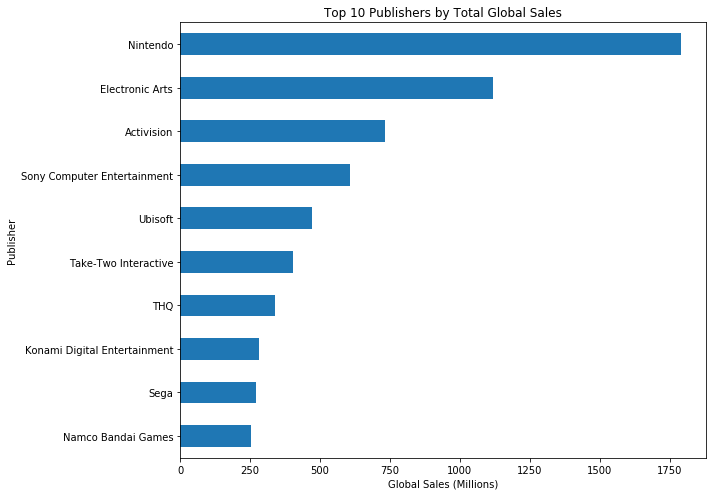


### Analysis

Among games with an available publisher, **Nintendo** has the highest
total global sales, with approximately **1788.81 million
units** across **706.0 games**.

These sales represent approximately **20.1%** of
the total global sales among games with an available publisher.

The top 10 publishers together account for approximately
**6264.64 million units**, representing
**70.4%** of the total global sales included in this
publisher-based analysis.

The comparison considers both total sales and the number of games represented
by each publisher, because publishers with more games can accumulate higher
total sales.


In [67]:
from IPython.display import display, Markdown

# Calculate total sales and number of games for each publisher
publisher_analysis = (
    df_clean.dropna(subset=['Publisher'])
    .groupby('Publisher')
    .agg(
        Total_Global_Sales=('Global_Sales', 'sum'),
        Number_of_Games=('Global_Sales', 'count')
    )
    .sort_values('Total_Global_Sales', ascending=False)
)

# Select top 10 publishers
top_publishers = publisher_analysis.head(10).copy()

# Calculate total sales among games with an available publisher
total_publisher_sales = publisher_analysis['Total_Global_Sales'].sum()

# Calculate percentage of total sales for each top publisher
top_publishers['Sales_Percentage'] = (
    top_publishers['Total_Global_Sales']
    / total_publisher_sales
) * 100

# Display the table
display(top_publishers)

# Identify highest-selling publisher
top_publisher = top_publishers.index[0]
top_publisher_sales = top_publishers.iloc[0]['Total_Global_Sales']
top_publisher_games = top_publishers.iloc[0]['Number_of_Games']
top_publisher_percentage = top_publishers.iloc[0]['Sales_Percentage']

# Combined sales of top 10 publishers
top_10_publisher_sales = top_publishers['Total_Global_Sales'].sum()

top_10_percentage = (
    top_10_publisher_sales / total_publisher_sales
) * 100

# Create the chart
plt.figure(figsize=(10, 7))

top_publishers['Total_Global_Sales'].sort_values(
    ascending=True
).plot(kind='barh')

plt.title('Top 10 Publishers by Total Global Sales')
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Publisher')

plt.tight_layout()
plt.show()

# Generate analysis dynamically
analysis_text = f"""
### Analysis

Among games with an available publisher, **{top_publisher}** has the highest
total global sales, with approximately **{top_publisher_sales:.2f} million
units** across **{top_publisher_games:,} games**.

These sales represent approximately **{top_publisher_percentage:.1f}%** of
the total global sales among games with an available publisher.

The top 10 publishers together account for approximately
**{top_10_publisher_sales:.2f} million units**, representing
**{top_10_percentage:.1f}%** of the total global sales included in this
publisher-based analysis.

The comparison considers both total sales and the number of games represented
by each publisher, because publishers with more games can accumulate higher
total sales.
"""

display(Markdown(analysis_text))

In [ ]:
# Average Global Sales per Game by Publisher

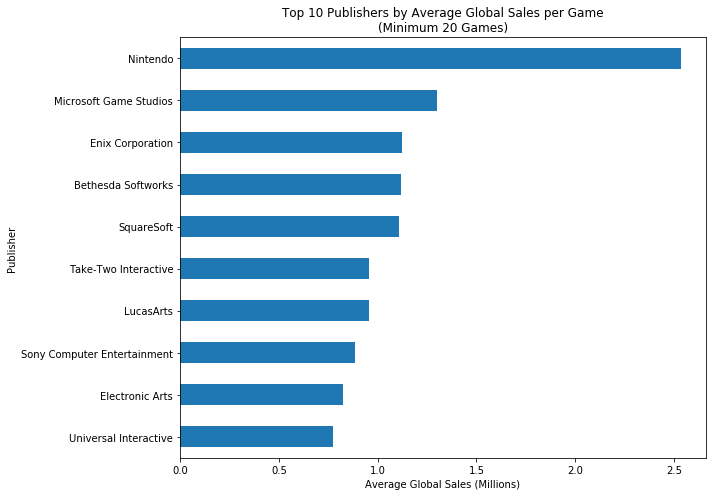

,Average_Global_Sales,Number_of_Games
Publisher,,
Nintendo,2.533725,706
Microsoft Game Studios,1.300105,191
Enix Corporation,1.124667,30
Bethesda Softworks,1.119079,76
SquareSoft,1.108654,52
Take-Two Interactive,0.956919,422
LucasArts,0.953667,90
Sony Computer Entertainment,0.882795,687
Electronic Arts,0.823717,1356



### Analysis

Among publishers with at least **20 games** in the dataset,
**Nintendo** has the highest average global sales per game, with
approximately **2.53 million units per game**.

This average is based on **706 games**.

Within the displayed top 10 publishers, the lowest average is recorded by
**Universal Interactive**, with approximately
**0.77 million units per game**, based on
**23 games**.

The difference between the highest and lowest average sales is approximately
**1.76 million units per game**.

A minimum of **20 games per publisher** was used to reduce the
effect of very small publisher samples. This makes the average-sales
comparison more stable than ranking publishers with only one or a few games.


In [69]:
from IPython.display import display, Markdown

# Minimum number of games required for a publisher
minimum_games = 20

# Calculate average sales and number of games for each publisher
publisher_avg_analysis = (
    df_clean.dropna(subset=['Publisher'])
    .groupby('Publisher')
    .agg(
        Average_Global_Sales=('Global_Sales', 'mean'),
        Number_of_Games=('Global_Sales', 'count')
    )
)

# Keep only publishers with at least 20 games
publisher_avg_filtered = (
    publisher_avg_analysis[
        publisher_avg_analysis['Number_of_Games'] >= minimum_games
    ]
    .sort_values('Average_Global_Sales', ascending=False)
)

# Select top 10 publishers
top_avg_publishers = publisher_avg_filtered.head(10)

# Identify highest average
highest_publisher = top_avg_publishers.index[0]
highest_average = top_avg_publishers.iloc[0]['Average_Global_Sales']
highest_game_count = top_avg_publishers.iloc[0]['Number_of_Games']

# Identify lowest average among displayed publishers
lowest_average = top_avg_publishers['Average_Global_Sales'].min()

lowest_publishers = top_avg_publishers[
    top_avg_publishers['Average_Global_Sales'] == lowest_average
].index.tolist()

lowest_game_count = top_avg_publishers.loc[
    lowest_publishers[0], 'Number_of_Games'
]

# Calculate difference
average_difference = highest_average - lowest_average

# Create the chart
plt.figure(figsize=(10, 7))

top_avg_publishers['Average_Global_Sales'].sort_values(
    ascending=True
).plot(kind='barh')

plt.title(
    'Top 10 Publishers by Average Global Sales per Game\n'
    f'(Minimum {minimum_games} Games)'
)

plt.xlabel('Average Global Sales (Millions)')
plt.ylabel('Publisher')

plt.tight_layout()
plt.show()

# Display the table
display(top_avg_publishers)

# Format lowest publisher names
if len(lowest_publishers) == 1:
    lowest_publisher_text = f"**{lowest_publishers[0]}**"
else:
    lowest_publisher_text = ", ".join(
        f"**{publisher}**"
        for publisher in lowest_publishers
    )

# Generate analysis dynamically
analysis_text = f"""
### Analysis

Among publishers with at least **{minimum_games} games** in the dataset,
**{highest_publisher}** has the highest average global sales per game, with
approximately **{highest_average:.2f} million units per game**.

This average is based on **{int(highest_game_count):,} games**.

Within the displayed top 10 publishers, the lowest average is recorded by
{lowest_publisher_text}, with approximately
**{lowest_average:.2f} million units per game**, based on
**{int(lowest_game_count):,} games**.

The difference between the highest and lowest average sales is approximately
**{average_difference:.2f} million units per game**.

A minimum of **{minimum_games} games per publisher** was used to reduce the
effect of very small publisher samples. This makes the average-sales
comparison more stable than ranking publishers with only one or a few games.
"""

display(Markdown(analysis_text))

In [70]:
# Key Findings Summary

from IPython.display import display, Markdown

# ---------------------------------------------------------
# 1. Genre findings
# ---------------------------------------------------------

genre_counts = df_clean['Genre'].value_counts()

top_genre = genre_counts.idxmax()
top_genre_count = genre_counts.max()

genre_sales = (
    df_clean.groupby('Genre')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
)

top_genre_sales = genre_sales.idxmax()
top_genre_sales_value = genre_sales.max()

genre_avg = (
    df_clean.groupby('Genre')['Global_Sales']
    .mean()
    .sort_values(ascending=False)
)

top_genre_avg = genre_avg.idxmax()
top_genre_avg_value = genre_avg.max()


# ---------------------------------------------------------
# 2. Platform findings
# ---------------------------------------------------------

platform_counts = df_clean['Platform'].value_counts()

top_platform = platform_counts.idxmax()
top_platform_count = platform_counts.max()

platform_sales = (
    df_clean.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
)

top_platform_sales = platform_sales.idxmax()
top_platform_sales_value = platform_sales.max()


# ---------------------------------------------------------
# 3. Overall sales distribution
# ---------------------------------------------------------

global_sales_mean = df_clean['Global_Sales'].mean()
global_sales_median = df_clean['Global_Sales'].median()
global_sales_max = df_clean['Global_Sales'].max()


# ---------------------------------------------------------
# 4. Critic Score relationship
# ---------------------------------------------------------

critic_data = df_clean[
    ['Critic_Score', 'Global_Sales']
].dropna()

critic_correlation = critic_data[
    'Critic_Score'
].corr(critic_data['Global_Sales'])


# ---------------------------------------------------------
# 5. User Score relationship
# ---------------------------------------------------------

user_data = df_clean[
    ['User_Score', 'Global_Sales']
].dropna()

user_correlation = user_data[
    'User_Score'
].corr(user_data['Global_Sales'])


# ---------------------------------------------------------
# 6. ESRB findings
# ---------------------------------------------------------

rating_counts = df_clean['Rating'].dropna().value_counts()

top_rating = rating_counts.idxmax()
top_rating_count = rating_counts.max()


# ---------------------------------------------------------
# 7. Year findings
# ---------------------------------------------------------

year_sales = (
    df_clean.dropna(subset=['Year_of_Release'])
    .groupby('Year_of_Release')['Global_Sales']
    .sum()
)

peak_sales_year = year_sales.idxmax()
peak_sales_year_value = year_sales.max()

year_games = (
    df_clean.dropna(subset=['Year_of_Release'])
    .groupby('Year_of_Release')
    .size()
)

peak_release_year = year_games.idxmax()
peak_release_count = year_games.max()


# ---------------------------------------------------------
# 8. Top-selling game
# ---------------------------------------------------------

top_game_row = df_clean.loc[
    df_clean['Global_Sales'].idxmax()
]

top_game_name = top_game_row['Name']
top_game_sales = top_game_row['Global_Sales']
top_game_platform = top_game_row['Platform']


# ---------------------------------------------------------
# 9. Publisher findings
# ---------------------------------------------------------

publisher_sales = (
    df_clean.dropna(subset=['Publisher'])
    .groupby('Publisher')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
)

top_publisher = publisher_sales.idxmax()
top_publisher_sales = publisher_sales.max()


# ---------------------------------------------------------
# 10. Dataset information
# ---------------------------------------------------------

total_games = len(df_clean)
total_columns = len(df_clean.columns)

missing_year_count = df_clean['Year_of_Release'].isna().sum()
missing_rating_count = df_clean['Rating'].isna().sum()


# ---------------------------------------------------------
# Display Key Findings
# ---------------------------------------------------------

summary_text = f"""
# Key Findings Summary

## Dataset Overview

The cleaned dataset contains **{total_games:,} games** and
**{total_columns} columns**.

There are **{missing_year_count:,} games** without an available release year
and **{missing_rating_count:,} games** without an available ESRB rating.
These records were retained and excluded only from analyses requiring the
corresponding information.

## Genre

**{top_genre}** is the most represented genre, with **{top_genre_count:,}
games**.

**{top_genre_sales}** has the highest total global sales among genres, with
approximately **{top_genre_sales_value:.2f} million units**.

**{top_genre_avg}** has the highest average global sales per game among
genres, with approximately **{top_genre_avg_value:.2f} million units per
game**.

## Platform

**{top_platform}** is the most represented platform, with
**{top_platform_count:,} games**.

**{top_platform_sales}** has the highest total global sales among platforms,
with approximately **{top_platform_sales_value:.2f} million units**.

## Global Sales

The average global sales per game are approximately
**{global_sales_mean:.2f} million units**, while the median is
**{global_sales_median:.2f} million units**.

The highest individual global sales value is approximately
**{global_sales_max:.2f} million units**.

The difference between the mean and median reflects the highly uneven
distribution of game sales.

## Ratings and Sales

The Pearson correlation between **Critic Score** and **Global Sales** is
approximately **{critic_correlation:.3f}**, indicating a weak positive linear
relationship in the available observations.

The Pearson correlation between **User Score** and **Global Sales** is
approximately **{user_correlation:.3f}**, also indicating a weak positive
linear relationship.

These correlations describe association and do not establish causation.

## ESRB Rating

Among games with an available ESRB rating, **{top_rating}** is the most common
rating, with **{top_rating_count:,} games**.

## Time-Based Findings

**{int(peak_sales_year)}** recorded the highest total global sales, with
approximately **{peak_sales_year_value:.2f} million units**.

**{int(peak_release_year)}** had the highest number of games released in the
dataset, with **{peak_release_count:,} games**.

The year with the highest total sales is therefore not necessarily the same
as the year with the highest number of games.

## Top-Selling Game

**{top_game_name}** is the highest-selling game in the dataset, with
approximately **{top_game_sales:.2f} million units** in global sales on the
**{top_game_platform}** platform.

## Publisher

**{top_publisher}** has the highest total global sales among publishers with
available publisher information, with approximately
**{top_publisher_sales:.2f} million units**.

---

### Overall Observation

The analysis shows substantial differences in game representation and sales
across genres, platforms, years, ratings, and publishers. Total sales,
average sales, and median sales provide different perspectives and should be
considered together when interpreting the dataset.
"""

display(Markdown(summary_text))


# Key Findings Summary

## Dataset Overview

The cleaned dataset contains **16,717 games** and
**16 columns**.

There are **269 games** without an available release year
and **6,767 games** without an available ESRB rating.
These records were retained and excluded only from analyses requiring the
corresponding information.

## Genre

**Action** is the most represented genre, with **3,370
games**.

**Action** has the highest total global sales among genres, with
approximately **1745.27 million units**.

**Platform** has the highest average global sales per game among
genres, with approximately **0.93 million units per
game**.

## Platform

**PS2** is the most represented platform, with
**2,161 games**.

**PS2** has the highest total global sales among platforms,
with approximately **1255.64 million units**.

## Global Sales

The average global sales per game are approximately
**0.53 million units**, while the median is
**0.17 million units**.

The highest individual global sales value is approximately
**82.53 million units**.

The difference between the mean and median reflects the highly uneven
distribution of game sales.

## Ratings and Sales

The Pearson correlation between **Critic Score** and **Global Sales** is
approximately **0.245**, indicating a weak positive linear
relationship in the available observations.

The Pearson correlation between **User Score** and **Global Sales** is
approximately **0.088**, also indicating a weak positive
linear relationship.

These correlations describe association and do not establish causation.

## ESRB Rating

Among games with an available ESRB rating, **E** is the most common
rating, with **3,991 games**.

## Time-Based Findings

**2008** recorded the highest total global sales, with
approximately **671.79 million units**.

**2008** had the highest number of games released in the
dataset, with **1,427 games**.

The year with the highest total sales is therefore not necessarily the same
as the year with the highest number of games.

## Top-Selling Game

**Wii Sports** is the highest-selling game in the dataset, with
approximately **82.53 million units** in global sales on the
**Wii** platform.

## Publisher

**Nintendo** has the highest total global sales among publishers with
available publisher information, with approximately
**1788.81 million units**.

---

### Overall Observation

The analysis shows substantial differences in game representation and sales
across genres, platforms, years, ratings, and publishers. Total sales,
average sales, and median sales provide different perspectives and should be
considered together when interpreting the dataset.
